# **CNN for digit classification of MNIST Dataset**

In [1]:
from __future__ import absolute_import, division, print_function, unicode_literals

import tensorflow as tf
from tensorflow import keras

from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [2]:
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

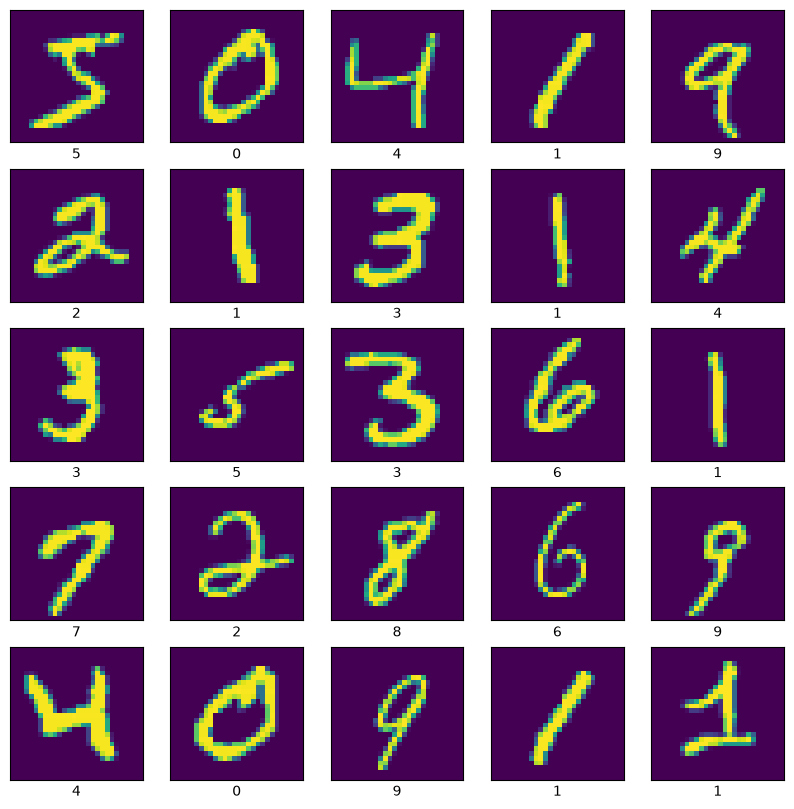

In [3]:
class_names = ['0', '1', '2', '3', '4',
               '5', '6', '7', '8', '9']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i]), #cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i]])
plt.show()

In [4]:
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_train.shape
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)
x_test.shape

(10000, 28, 28, 1)

In [5]:
x_train.shape

(60000, 28, 28, 1)

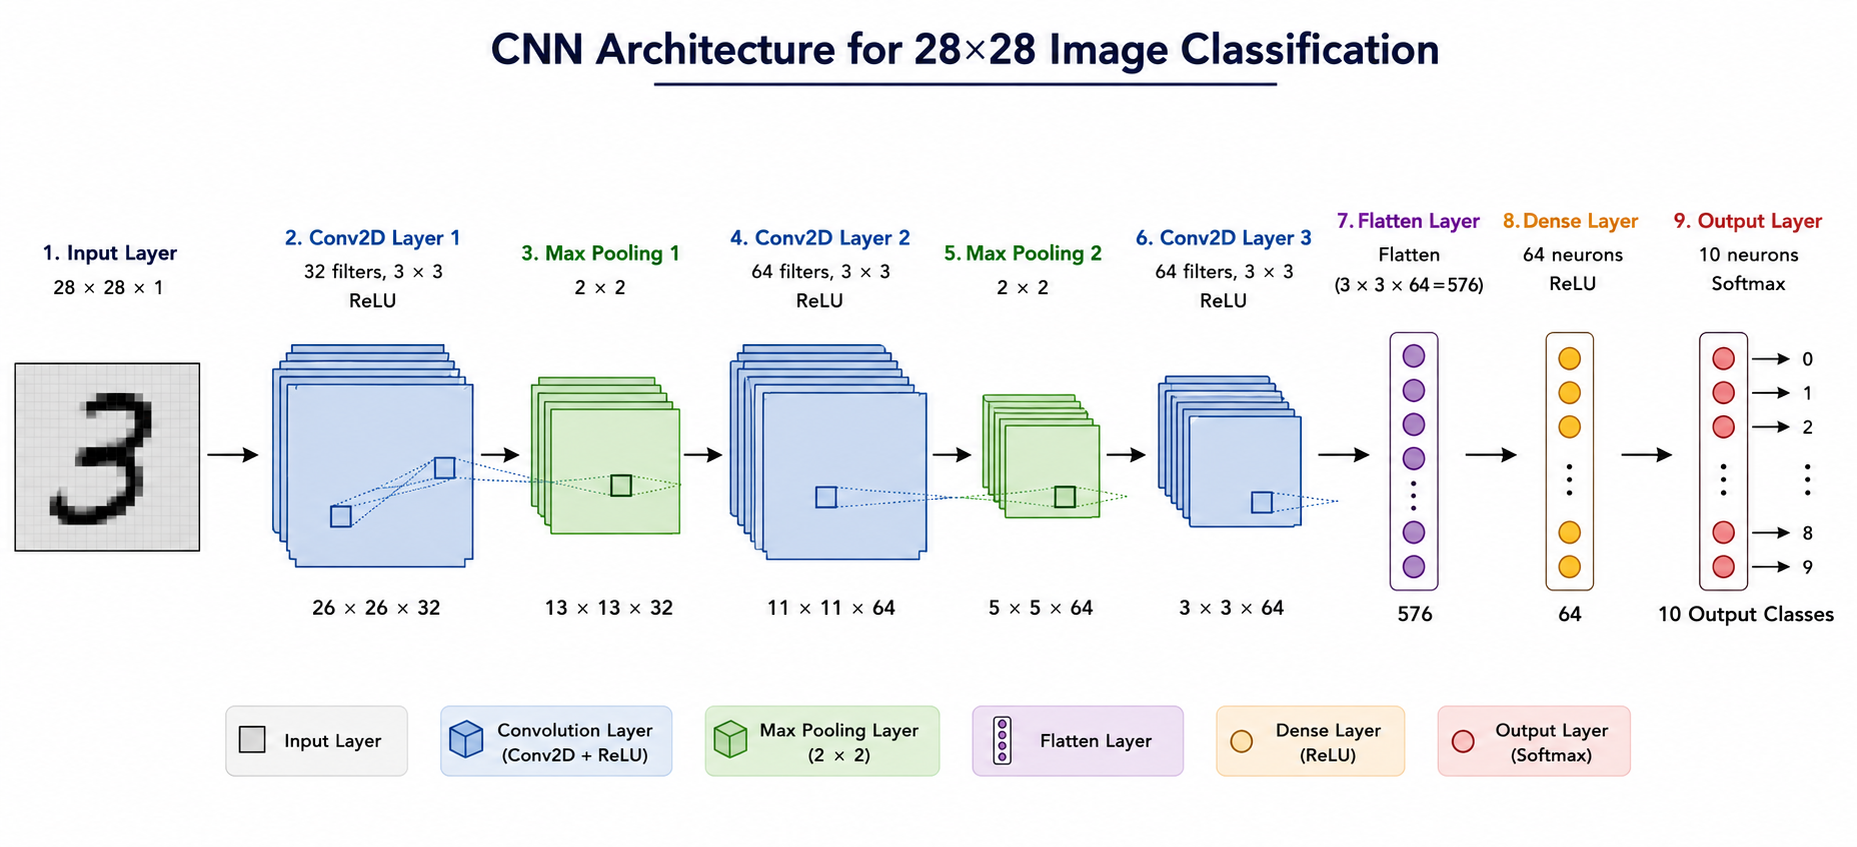

In [6]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28,28,1))),
model.add(layers.MaxPooling2D((2, 2))),
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2))),
model.add(layers.Conv2D(64, (3, 3), activation='relu')),
model.add(layers.Flatten()),
model.add(layers.Dense(64, activation='relu')),
model.add(layers.Dense(10,activation='softmax'))

c:\Users\sudar\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

Epoch 1/10


c:\Users\sudar\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\backend\tensorflow\nn.py:1402: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9521 - loss: 0.1515 - val_accuracy: 0.9825 - val_loss: 0.0509
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9848 - loss: 0.0478 - val_accuracy: 0.9869 - val_loss: 0.0405
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9893 - loss: 0.0349 - val_accuracy: 0.9905 - val_loss: 0.0290
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9915 - loss: 0.0265 - val_accuracy: 0.9901 - val_loss: 0.0300
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9930 - loss: 0.0210 - val_accuracy: 0.9895 - val_loss: 0.0347
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9948 - loss: 0.0162 - val_accuracy: 0.9901 - val_loss: 0.0345
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.9956 - loss: 0.0138 - val_accuracy: 0.9882 - val_loss: 0.0488
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9958 - loss: 0.0126 - val_

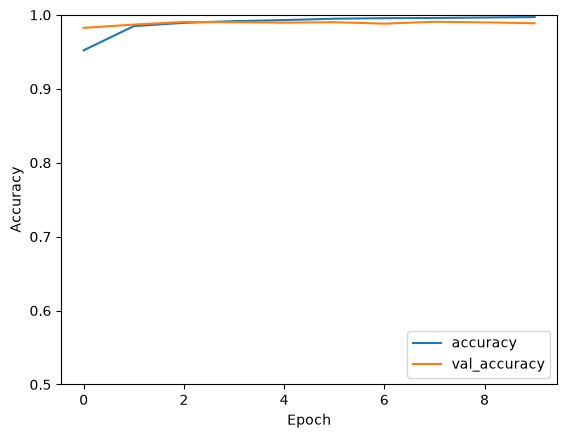

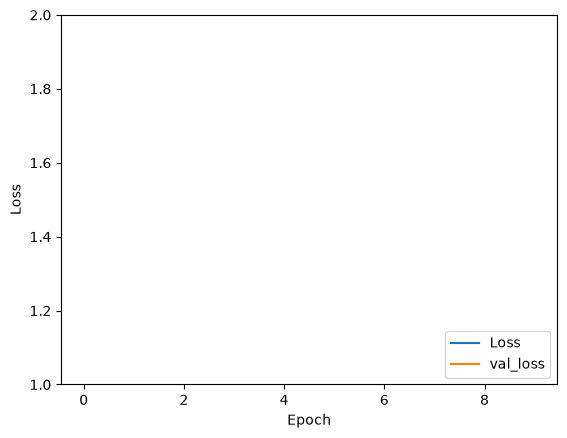

313/313 - 1s - 4ms/step - accuracy: 0.9887 - loss: 0.0501


In [9]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
plt.show()
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim([1,2])
plt.legend(loc='lower right')
plt.show()

test_loss, test_acc = model.evaluate(x_test,y_test, verbose=2)

In [10]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9887 - loss: 0.0501


[0.05006999149918556, 0.9886999726295471]

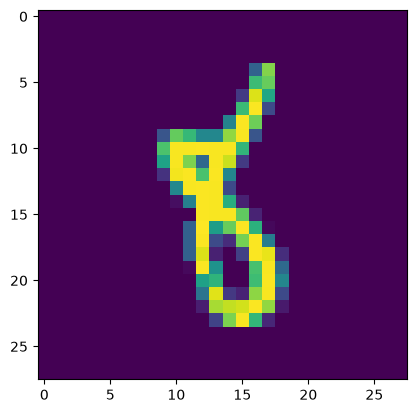

In [11]:
import matplotlib.pyplot as plt
x_test = x_test.reshape(x_test.shape[0], 28, 28)
plt.imshow(x_test[5678])
plt.show()

In [12]:
x_test[5678].shape

(28, 28)

In [13]:
x_test = x_test.reshape(x_test.shape[0], 28, 28,1)
predictions = model.predict(x_test)
print(predictions[5678])
np.argmax(predictions[5678])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
[2.4426891e-13 1.0109764e-09 5.0375643e-10 4.8649728e-08 3.3868267e-13
 2.1941627e-08 2.4012374e-07 4.4360907e-13 9.9999964e-01 3.0427895e-13]


np.int64(8)

In [14]:
y_test

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,), dtype=uint8)

In [15]:
pred=[]
for j in range(len(predictions)):
   pred.append(np.argmax(predictions[j]))

In [16]:
import sklearn
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,pred)

array([[ 977,    0,    1,    0,    1,    0,    0,    1,    0,    0],
       [   0, 1130,    1,    1,    0,    0,    1,    2,    0,    0],
       [   0,    1, 1025,    0,    2,    0,    0,    4,    0,    0],
       [   0,    0,    2, 1003,    0,    2,    0,    3,    0,    0],
       [   0,    0,    0,    0,  980,    0,    0,    0,    0,    2],
       [   0,    0,    0,   10,    0,  875,    1,    0,    3,    3],
       [   2,    2,    0,    0,   14,    2,  937,    0,    1,    0],
       [   0,    2,    3,    0,    3,    0,    0, 1015,    1,    4],
       [   3,    0,    1,    2,    1,    0,    0,    3,  955,    9],
       [   0,    0,    1,    0,   11,    4,    0,    3,    0,  990]])

In [17]:
from sklearn.metrics import classification_report
print(classification_report(y_test,pred, target_names=class_names))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       1.00      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.97      1.00      0.98       982
           5       0.99      0.98      0.99       892
           6       1.00      0.98      0.99       958
           7       0.98      0.99      0.99      1028
           8       0.99      0.98      0.99       974
           9       0.98      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [18]:
print('Accuracy:', sklearn.metrics.accuracy_score(y_test,pred))

print('F1 score:',sklearn.metrics.f1_score(y_test,pred,
                            average='weighted'))

print( 'Recall:',sklearn.metrics.recall_score(y_test,pred,
                              average='weighted'))

print('Precision:',sklearn.metrics.precision_score(y_test,pred,
                                    average='weighted'))

Accuracy: 0.9887
F1 score: 0.9887043730189861
Recall: 0.9887
Precision: 0.9887886753821569


model = models.Sequential()

model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28,28,1)))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

# A. Experiment with number of convoltution Filters

1. Change to 16-32-32
2. Change to 32-64-64
3. Change to 64-128-128

**Answer following questions**:
1. Does increasing the number of filters always improve accuracy?
2. How does the number of parameters change?
3. How does training time change?
4. Which architecture gives the best trade-off between accuracy and computational cost?


In [30]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import time

def create_cnn(filters):
    model = models.Sequential([
        layers.Conv2D(filters[0], (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(filters[1], (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(filters[2], (3, 3), activation='relu'),

        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10)
    ])

    return model

In [31]:
# Prepare MNIST data for CNN
x_train_cnn = x_train[..., tf.newaxis]
x_test_cnn = x_test[..., tf.newaxis]

print("Training data shape:", x_train_cnn.shape)
print("Test data shape:", x_test_cnn.shape)

Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)


In [32]:
model_16_32_32 = models.Sequential([
    layers.Conv2D(16, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation='relu'),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

In [33]:
model_16_32_32.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [22]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9918 - loss: 0.0347
Test Accuracy: 0.9918000102043152


In [34]:
model_16_32_32.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 3, 3, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,194 (129.66 KB)

 Trainable params: 33,194 (129.66 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
start_time_16_32_32 = time.time()

history_16_32_32 = model_16_32_32.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

training_time_16_32_32 = time.time() - start_time_16_32_32

print("Training time:", training_time_16_32_32, "seconds")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9294 - loss: 0.2357 - val_accuracy: 0.9812 - val_loss: 0.0712
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9802 - loss: 0.0648 - val_accuracy: 0.9858 - val_loss: 0.0499
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9854 - loss: 0.0471 - val_accuracy: 0.9895 - val_loss: 0.0387
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9883 - loss: 0.0388 - val_accuracy: 0.9892 - val_loss: 0.0415
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9899 - loss: 0.0317 - val_accuracy: 0.9888 - val_loss: 0.0421
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9915 - loss: 0.0266 - val_accuracy: 0.9893 - val_loss: 0.0468
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9925 - loss: 0.0229 - val_accuracy: 0.9885 - val_loss: 0.0448
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9938 - loss: 0.0193 - val_accuracy: 0.

In [36]:
test_loss_16_32_32, test_accuracy_16_32_32 = model_16_32_32.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("Test Loss:", test_loss_16_32_32)
print("Test Accuracy:", test_accuracy_16_32_32)

313/313 - 1s - 3ms/step - accuracy: 0.9915 - loss: 0.0295
Test Loss: 0.029495596885681152
Test Accuracy: 0.9915000200271606


In [37]:
model_32_64_64 = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

In [38]:
model_32_64_64.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [39]:
model_32_64_64.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
start_time_32_64_64 = time.time()

history_32_64_64 = model_32_64_64.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

training_time_32_64_64 = time.time() - start_time_32_64_64

print("Training time:", training_time_32_64_64, "seconds")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9376 - loss: 0.2048 - val_accuracy: 0.9777 - val_loss: 0.0762
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9815 - loss: 0.0595 - val_accuracy: 0.9857 - val_loss: 0.0484
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9875 - loss: 0.0409 - val_accuracy: 0.9890 - val_loss: 0.0358
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9900 - loss: 0.0313 - val_accuracy: 0.9870 - val_loss: 0.0534
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9916 - loss: 0.0258 - val_accuracy: 0.9910 - val_loss: 0.0377
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9928 - loss: 0.0214 - val_accuracy: 0.9892 - val_loss: 0.0371
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9947 - loss: 0.0165 - val_accuracy: 0.9898 - val_loss: 0.0417
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9949 - loss: 0.0152 - val_accuracy: 

In [41]:
test_loss_32_64_64, test_accuracy_32_64_64 = model_32_64_64.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("Test Loss:", test_loss_32_64_64)
print("Test Accuracy:", test_accuracy_32_64_64)

313/313 - 1s - 3ms/step - accuracy: 0.9912 - loss: 0.0351
Test Loss: 0.03508589416742325
Test Accuracy: 0.9911999702453613


In [42]:
model_64_128_128 = models.Sequential([
    layers.Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

In [43]:
model_64_128_128.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [44]:
model_64_128_128.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 3, 3, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 296,522 (1.13 MB)

 Trainable params: 296,522 (1.13 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
start_time_64_128_128 = time.time()

history_64_128_128 = model_64_128_128.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

training_time_64_128_128 = time.time() - start_time_64_128_128

print("Training time:", training_time_64_128_128, "seconds")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - accuracy: 0.9486 - loss: 0.1608 - val_accuracy: 0.9880 - val_loss: 0.0432
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.9853 - loss: 0.0462 - val_accuracy: 0.9898 - val_loss: 0.0366
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.9898 - loss: 0.0310 - val_accuracy: 0.9883 - val_loss: 0.0427
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.9920 - loss: 0.0246 - val_accuracy: 0.9912 - val_loss: 0.0353
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.9933 - loss: 0.0194 - val_accuracy: 0.9883 - val_loss: 0.0519
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.9949 - loss: 0.0154 - val_accuracy: 0.9925 - val_loss: 0.0277
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.9966 - loss: 0.0109 - val_accuracy: 0.9903 - val_loss: 0.0416
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.9960 - loss: 0.0119 - 

In [46]:
test_loss_64_128_128, test_accuracy_64_128_128 = model_64_128_128.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("Test Loss:", test_loss_64_128_128)
print("Test Accuracy:", test_accuracy_64_128_128)

313/313 - 2s - 5ms/step - accuracy: 0.9905 - loss: 0.0388
Test Loss: 0.03877587616443634
Test Accuracy: 0.9904999732971191


In [47]:
print("========== FILTER COMPARISON ==========")

print("\n16-32-32")
print("Test Accuracy :", test_accuracy_16_32_32)
print("Test Loss     :", test_loss_16_32_32)
print("Training Time :", training_time_16_32_32, "seconds")

print("\n32-64-64")
print("Test Accuracy :", test_accuracy_32_64_64)
print("Test Loss     :", test_loss_32_64_64)
print("Training Time :", training_time_32_64_64, "seconds")

print("\n64-128-128")
print("Test Accuracy :", test_accuracy_64_128_128)
print("Test Loss     :", test_loss_64_128_128)
print("Training Time :", training_time_64_128_128, "seconds")

========== FILTER COMPARISON ==========

16-32-32
Test Accuracy : 0.9915000200271606
Test Loss     : 0.029495596885681152
Training Time : 47.27034521102905 seconds

32-64-64
Test Accuracy : 0.9911999702453613
Test Loss     : 0.03508589416742325
Training Time : 79.5247700214386 seconds

64-128-128
Test Accuracy : 0.9904999732971191
Test Loss     : 0.03877587616443634
Training Time : 167.32419967651367 seconds


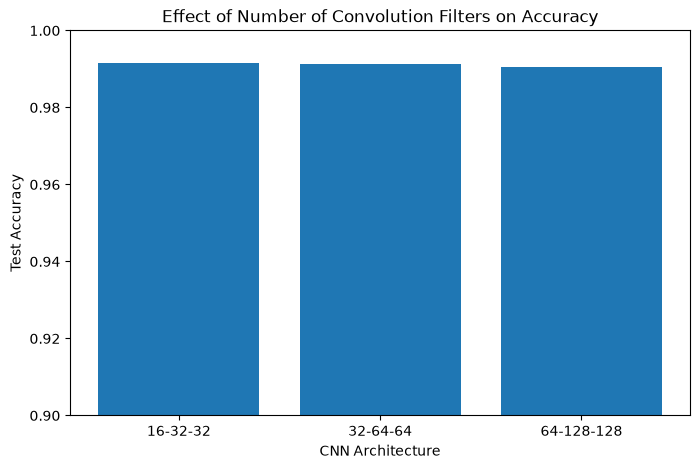

In [48]:
architectures = ['16-32-32', '32-64-64', '64-128-128']

accuracies = [
    test_accuracy_16_32_32,
    test_accuracy_32_64_64,
    test_accuracy_64_128_128
]

plt.figure(figsize=(8, 5))
plt.bar(architectures, accuracies)

plt.xlabel("CNN Architecture")
plt.ylabel("Test Accuracy")
plt.title("Effect of Number of Convolution Filters on Accuracy")
plt.ylim(0.9, 1.0)

plt.show()

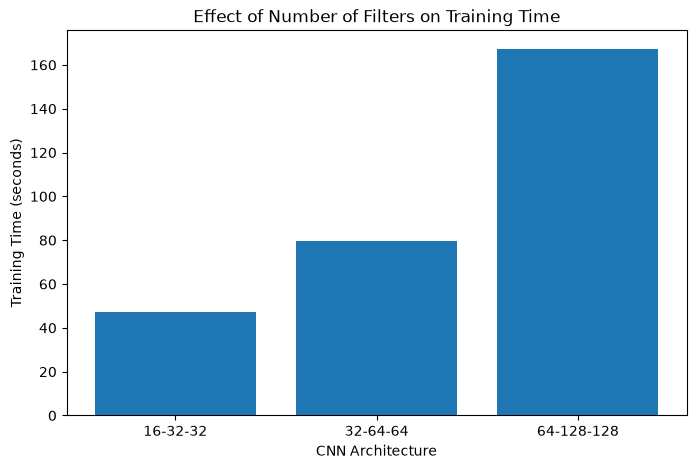

In [49]:
training_times = [
    training_time_16_32_32,
    training_time_32_64_64,
    training_time_64_128_128
]

plt.figure(figsize=(8, 5))
plt.bar(architectures, training_times)

plt.xlabel("CNN Architecture")
plt.ylabel("Training Time (seconds)")
plt.title("Effect of Number of Filters on Training Time")

plt.show()

In [50]:
print("16-32-32 parameters:", model_16_32_32.count_params())
print("32-64-64 parameters:", model_32_64_64.count_params())
print("64-128-128 parameters:", model_64_128_128.count_params())

16-32-32 parameters: 33194
32-64-64 parameters: 93322
64-128-128 parameters: 296522


# 1. Does increasing the number of filters always improve accuracy?

No, increasing the number of convolution filters does not always improve accuracy. In our experiment, the 16-32-32 architecture achieved the highest test accuracy of 99.15%. The accuracy slightly decreased to 99.12% for 32-64-64 and 99.05% for 64-128-128.

Therefore, increasing the number of filters increased the model complexity but did not improve classification accuracy for this MNIST experiment.

# 2. How does the number of parameters change?

The number of parameters increases significantly as the number of filters increases.

16-32-32: 33,194 parameters
32-64-64: 93,322 parameters
64-128-128: 296,522 parameters

Thus, increasing the filters makes the CNN much larger. The 64-128-128 model has almost 9 times more parameters than the 16-32-32 model.

# 3. How does training time change?

Training time increases considerably with the number of filters.

16-32-32: 47.27 seconds
32-64-64: 79.52 seconds
64-128-128: 167.32 seconds

The 64-128-128 architecture took the longest because it performs more convolution operations with a larger number of filters. Therefore, increasing the number of filters increases the computational cost and training time.

# 4. Which architecture gives the best trade-off between accuracy and computational cost?

The 16-32-32 architecture gives the best trade-off between accuracy and computational cost.

It achieved the highest test accuracy of 99.15%, while having the lowest number of parameters (33,194) and the shortest training time (47.27 seconds).

Although 32-64-64 and 64-128-128 have more filters and significantly more parameters, they did not provide better accuracy. Therefore, for this experiment, 16-32-32 is the most efficient architecture.

# **B. Experiment with Kernel Size**

Compare 3x3 with 5x5

**Answer following questions**:
1. Which kernel size gives better accuracy?
2. How does kernel size affect the number of parameters?
3. How does it affect the spatial dimensions of feature maps?
4. Why might smaller 3×3 kernels be effective?

In [51]:
model_3x3 = models.Sequential([
    layers.Conv2D(
        32, (3, 3),
        activation='relu',
        padding='same',
        input_shape=(28, 28, 1)
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu',
        padding='same'
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu',
        padding='same'
    ),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

In [52]:
model_3x3.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [53]:
model_3x3.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 257,162 (1004.54 KB)

 Trainable params: 257,162 (1004.54 KB)

 Non-trainable params: 0 (0.00 B)

In [54]:
start_time_3x3 = time.time()

history_3x3 = model_3x3.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

training_time_3x3 = time.time() - start_time_3x3

print("Training time:", training_time_3x3, "seconds")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9481 - loss: 0.1653 - val_accuracy: 0.9845 - val_loss: 0.0510
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9860 - loss: 0.0463 - val_accuracy: 0.9882 - val_loss: 0.0415
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9895 - loss: 0.0328 - val_accuracy: 0.9922 - val_loss: 0.0306
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9920 - loss: 0.0254 - val_accuracy: 0.9908 - val_loss: 0.0289
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9939 - loss: 0.0191 - val_accuracy: 0.9903 - val_loss: 0.0331
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9953 - loss: 0.0152 - val_accuracy: 0.9908 - val_loss: 0.0339
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9954 - loss: 0.0139 - val_accuracy: 0.9913 - val_loss: 0.0323
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9959 - loss: 0.0118 - v

In [55]:
test_loss_3x3, test_accuracy_3x3 = model_3x3.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("Test Loss:", test_loss_3x3)
print("Test Accuracy:", test_accuracy_3x3)

313/313 - 1s - 5ms/step - accuracy: 0.9887 - loss: 0.0412
Test Loss: 0.04122210294008255
Test Accuracy: 0.9886999726295471


In [56]:
model_5x5 = models.Sequential([
    layers.Conv2D(
        32, (5, 5),
        activation='relu',
        padding='same',
        input_shape=(28, 28, 1)
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (5, 5),
        activation='relu',
        padding='same'
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (5, 5),
        activation='relu',
        padding='same'
    ),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

In [57]:
model_5x5.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [58]:
model_5x5.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 14, 14, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 7, 7, 64)       │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,978 (1.36 MB)

 Trainable params: 355,978 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [59]:
start_time_5x5 = time.time()

history_5x5 = model_5x5.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

training_time_5x5 = time.time() - start_time_5x5

print("Training time:", training_time_5x5, "seconds")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - accuracy: 0.9532 - loss: 0.1486 - val_accuracy: 0.9847 - val_loss: 0.0545
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.9867 - loss: 0.0437 - val_accuracy: 0.9887 - val_loss: 0.0363
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.9911 - loss: 0.0285 - val_accuracy: 0.9885 - val_loss: 0.0361
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.9928 - loss: 0.0228 - val_accuracy: 0.9907 - val_loss: 0.0325
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.9945 - loss: 0.0163 - val_accuracy: 0.9925 - val_loss: 0.0274
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.9954 - loss: 0.0150 - val_accuracy: 0.9925 - val_loss: 0.0294
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.9964 - loss: 0.0113 - val_accuracy: 0.9913 - val_loss: 0.0373
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.9967 - loss: 0.0097 - 

In [60]:
test_loss_5x5, test_accuracy_5x5 = model_5x5.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("Test Loss:", test_loss_5x5)
print("Test Accuracy:", test_accuracy_5x5)

313/313 - 2s - 6ms/step - accuracy: 0.9931 - loss: 0.0275
Test Loss: 0.027511609718203545
Test Accuracy: 0.9930999875068665


In [61]:
print("========== KERNEL SIZE COMPARISON ==========")

print("\n3x3 Kernel")
print("Parameters   :", model_3x3.count_params())
print("Test Loss    :", test_loss_3x3)
print("Test Accuracy:", test_accuracy_3x3)
print("Training Time:", training_time_3x3, "seconds")

print("\n5x5 Kernel")
print("Parameters   :", model_5x5.count_params())
print("Test Loss    :", test_loss_5x5)
print("Test Accuracy:", test_accuracy_5x5)
print("Training Time:", training_time_5x5, "seconds")

========== KERNEL SIZE COMPARISON ==========

3x3 Kernel
Parameters   : 257162
Test Loss    : 0.04122210294008255
Test Accuracy: 0.9886999726295471
Training Time: 103.62540555000305 seconds

5x5 Kernel
Parameters   : 355978
Test Loss    : 0.027511609718203545
Test Accuracy: 0.9930999875068665
Training Time: 161.76262187957764 seconds


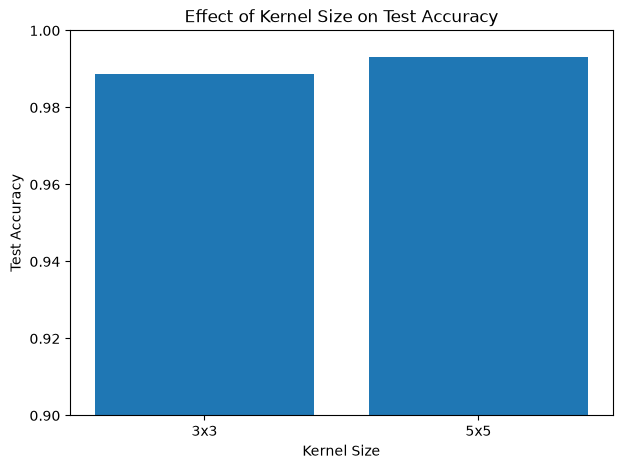

In [62]:
kernel_sizes = ['3x3', '5x5']

kernel_accuracies = [
    test_accuracy_3x3,
    test_accuracy_5x5
]

plt.figure(figsize=(7, 5))

plt.bar(kernel_sizes, kernel_accuracies)

plt.xlabel("Kernel Size")
plt.ylabel("Test Accuracy")
plt.title("Effect of Kernel Size on Test Accuracy")
plt.ylim(0.9, 1.0)

plt.show()

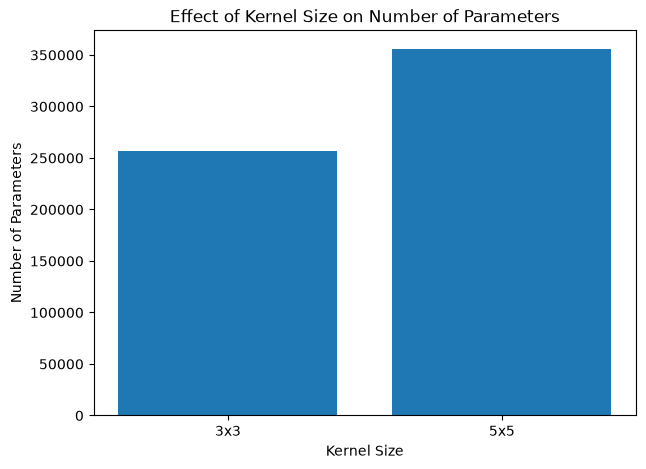

In [63]:
kernel_parameters = [
    model_3x3.count_params(),
    model_5x5.count_params()
]

plt.figure(figsize=(7, 5))

plt.bar(kernel_sizes, kernel_parameters)

plt.xlabel("Kernel Size")
plt.ylabel("Number of Parameters")
plt.title("Effect of Kernel Size on Number of Parameters")

plt.show()

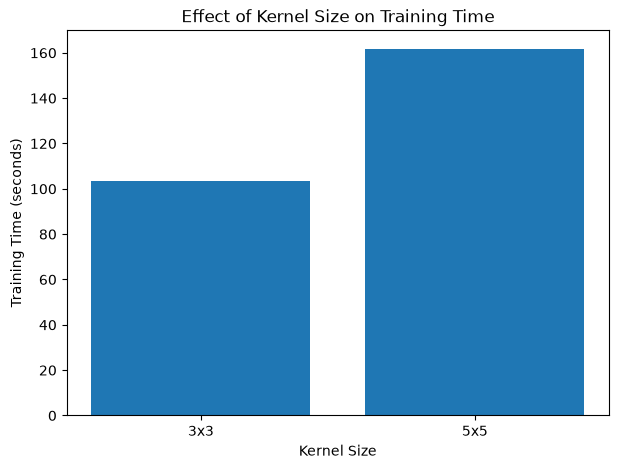

In [64]:
kernel_training_times = [
    training_time_3x3,
    training_time_5x5
]

plt.figure(figsize=(7, 5))

plt.bar(kernel_sizes, kernel_training_times)

plt.xlabel("Kernel Size")
plt.ylabel("Training Time (seconds)")
plt.title("Effect of Kernel Size on Training Time")

plt.show()

In [65]:
print("========== FEATURE MAP DIMENSIONS ==========")

print("\nInput:")
print("28 x 28")

print("\nAfter Conv1:")
print("3x3 → 28 x 28 x 32")
print("5x5 → 28 x 28 x 32")

print("\nAfter Pool1:")
print("3x3 → 14 x 14 x 32")
print("5x5 → 14 x 14 x 32")

print("\nAfter Conv2:")
print("3x3 → 14 x 14 x 64")
print("5x5 → 14 x 14 x 64")

print("\nAfter Pool2:")
print("3x3 → 7 x 7 x 64")
print("5x5 → 7 x 7 x 64")

print("\nAfter Conv3:")
print("3x3 → 7 x 7 x 64")
print("5x5 → 7 x 7 x 64")

========== FEATURE MAP DIMENSIONS ==========

Input:
28 x 28

After Conv1:
3x3 → 28 x 28 x 32
5x5 → 28 x 28 x 32

After Pool1:
3x3 → 14 x 14 x 32
5x5 → 14 x 14 x 32

After Conv2:
3x3 → 14 x 14 x 64
5x5 → 14 x 14 x 64

After Pool2:
3x3 → 7 x 7 x 64
5x5 → 7 x 7 x 64

After Conv3:
3x3 → 7 x 7 x 64
5x5 → 7 x 7 x 64


# 1. Which kernel size gives better accuracy?

In our experiment, the 5×5 kernel gives better accuracy.

3×3: 98.87%
5×5: 99.31%

Therefore, the 5×5 kernel performed better on the MNIST test set, improving the accuracy by approximately 0.44 percentage points compared with the 3×3 kernel.

# 2. How does kernel size affect the number of parameters?

Increasing the kernel size increases the number of trainable parameters because each filter contains more weights.

3×3: 257,162 parameters
5×5: 355,978 parameters

The 5×5 model has 98,816 more parameters than the 3×3 model. Therefore, larger kernels increase model complexity and memory requirements.

For example, a 3×3 kernel has 9 weights per input channel, while a 5×5 kernel has 25 weights per input channel.

# 3. How does it affect the spatial dimensions of feature maps?

In this experiment, we used padding='same', so changing the kernel from 3×3 to 5×5 does not change the spatial dimensions of the feature maps.

The dimensions are:

Stage	Feature Map
Input	28 × 28 × 1
After Conv1	28 × 28 × 32
After Pool1	14 × 14 × 32
After Conv2	14 × 14 × 64
After Pool2	7 × 7 × 64
After Conv3	7 × 7 × 64

Thus, both 3×3 and 5×5 models produce the same spatial dimensions because of same padding. The MaxPooling layers, rather than the kernel size, reduce the spatial dimensions.

# 4. Why might smaller 3×3 kernels be effective?

Smaller 3×3 kernels can be effective because they require fewer parameters and less computation than 5×5 kernels. This makes the model faster and more computationally efficient.

A 3×3 kernel contains only 9 spatial weights, compared with 25 weights for a 5×5 kernel. Smaller kernels can also be stacked across multiple convolutional layers to gradually capture complex features while keeping the number of parameters relatively low.

In our experiment, the 3×3 model had fewer parameters and a shorter training time, although the 5×5 model achieved higher accuracy on MNIST.

# C. CNN Depth experimentation with

**Model A** - One convolutional layer  32 filters of 3x3

**Model B** - Two convolutional layer  32- 64 filters of 3x3

**Model C** - Three convolutional layer 32-64-64 filters of 3x3

**Answer the following Questions**:

1. How does increasing network depth affect classification accuracy?
2. Does adding more layers always improve performance?
3. Which model has the best accuracy–complexity trade-off?



In [66]:
model_A = models.Sequential([
    layers.Conv2D(
        32, (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),
    
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

In [67]:
model_A.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [68]:
model_A.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,146 (1.32 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

In [69]:
start_time_A = time.time()

history_A = model_A.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

training_time_A = time.time() - start_time_A

print("Model A Training Time:", training_time_A, "seconds")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9400 - loss: 0.2087 - val_accuracy: 0.9800 - val_loss: 0.0755
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9792 - loss: 0.0708 - val_accuracy: 0.9862 - val_loss: 0.0519
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9852 - loss: 0.0494 - val_accuracy: 0.9863 - val_loss: 0.0480
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9880 - loss: 0.0385 - val_accuracy: 0.9865 - val_loss: 0.0475
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9916 - loss: 0.0284 - val_accuracy: 0.9885 - val_loss: 0.0437
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9929 - loss: 0.0227 - val_accuracy: 0.9883 - val_loss: 0.0460
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9945 - loss: 0.0170 - val_accuracy: 0.9870 - val_loss: 0.0561
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9960 - loss: 0.0127 - val_accuracy: 0.

In [70]:
test_loss_A, test_accuracy_A = model_A.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("Model A Test Loss:", test_loss_A)
print("Model A Test Accuracy:", test_accuracy_A)

313/313 - 1s - 2ms/step - accuracy: 0.9852 - loss: 0.0504
Model A Test Loss: 0.05038309097290039
Model A Test Accuracy: 0.9851999878883362


In [71]:
model_B = models.Sequential([
    layers.Conv2D(
        32, (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),
    
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),
    
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

In [72]:
model_B.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [73]:
model_B.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_19 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [74]:
start_time_B = time.time()

history_B = model_B.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

training_time_B = time.time() - start_time_B

print("Model B Training Time:", training_time_B, "seconds")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9425 - loss: 0.1895 - val_accuracy: 0.9815 - val_loss: 0.0665
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9826 - loss: 0.0552 - val_accuracy: 0.9882 - val_loss: 0.0422
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9885 - loss: 0.0382 - val_accuracy: 0.9892 - val_loss: 0.0395
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9913 - loss: 0.0280 - val_accuracy: 0.9878 - val_loss: 0.0399
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9931 - loss: 0.0214 - val_accuracy: 0.9912 - val_loss: 0.0358
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9943 - loss: 0.0182 - val_accuracy: 0.9903 - val_loss: 0.0374
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9958 - loss: 0.0140 - val_accuracy: 0.9913 - val_loss: 0.0374
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9963 - loss: 0.0110 - val_accuracy: 0

In [75]:
test_loss_B, test_accuracy_B = model_B.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("Model B Test Loss:", test_loss_B)
print("Model B Test Accuracy:", test_accuracy_B)

313/313 - 1s - 3ms/step - accuracy: 0.9919 - loss: 0.0303
Model B Test Loss: 0.03030894696712494
Model B Test Accuracy: 0.9919000267982483


In [76]:
model_C = models.Sequential([
    layers.Conv2D(
        32, (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),
    
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),
    
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

In [77]:
model_C.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [78]:
model_C.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [79]:
start_time_C = time.time()

history_C = model_C.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

training_time_C = time.time() - start_time_C

print("Model C Training Time:", training_time_C, "seconds")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9400 - loss: 0.1984 - val_accuracy: 0.9832 - val_loss: 0.0591
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9827 - loss: 0.0550 - val_accuracy: 0.9793 - val_loss: 0.0635
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9870 - loss: 0.0397 - val_accuracy: 0.9880 - val_loss: 0.0370
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9907 - loss: 0.0303 - val_accuracy: 0.9907 - val_loss: 0.0325
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9922 - loss: 0.0246 - val_accuracy: 0.9895 - val_loss: 0.0374
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9929 - loss: 0.0203 - val_accuracy: 0.9927 - val_loss: 0.0302
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9946 - loss: 0.0162 - val_accuracy: 0.9918 - val_loss: 0.0310
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9952 - loss: 0.0150 - val_accuracy: 

In [80]:
test_loss_C, test_accuracy_C = model_C.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("Model C Test Loss:", test_loss_C)
print("Model C Test Accuracy:", test_accuracy_C)

313/313 - 1s - 3ms/step - accuracy: 0.9896 - loss: 0.0393
Model C Test Loss: 0.039320170879364014
Model C Test Accuracy: 0.9896000027656555


In [81]:
print("========== CNN DEPTH COMPARISON ==========")

print("\nModel A - 1 Convolutional Layer")
print("Parameters   :", model_A.count_params())
print("Test Loss    :", test_loss_A)
print("Test Accuracy:", test_accuracy_A)
print("Training Time:", training_time_A, "seconds")

print("\nModel B - 2 Convolutional Layers")
print("Parameters   :", model_B.count_params())
print("Test Loss    :", test_loss_B)
print("Test Accuracy:", test_accuracy_B)
print("Training Time:", training_time_B, "seconds")

print("\nModel C - 3 Convolutional Layers")
print("Parameters   :", model_C.count_params())
print("Test Loss    :", test_loss_C)
print("Test Accuracy:", test_accuracy_C)
print("Training Time:", training_time_C, "seconds")

========== CNN DEPTH COMPARISON ==========

Model A - 1 Convolutional Layer
Parameters   : 347146
Test Loss    : 0.05038309097290039
Test Accuracy: 0.9851999878883362
Training Time: 59.76442050933838 seconds

Model B - 2 Convolutional Layers
Parameters   : 121930
Test Loss    : 0.03030894696712494
Test Accuracy: 0.9919000267982483
Training Time: 76.82759857177734 seconds

Model C - 3 Convolutional Layers
Parameters   : 93322
Test Loss    : 0.039320170879364014
Test Accuracy: 0.9896000027656555
Training Time: 80.71035623550415 seconds


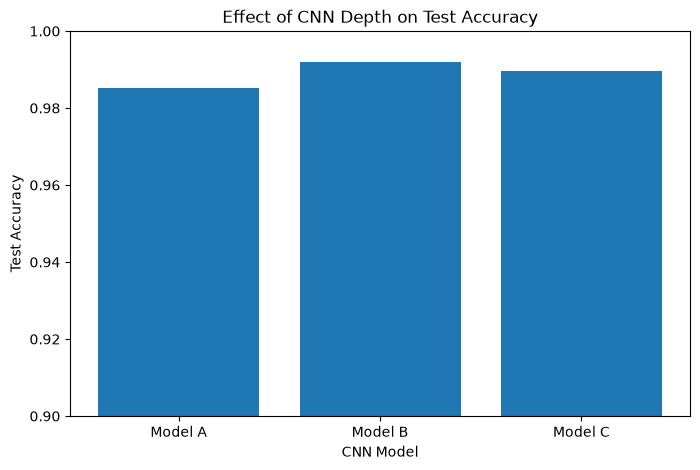

In [82]:
models_names = ['Model A', 'Model B', 'Model C']

depth_accuracies = [
    test_accuracy_A,
    test_accuracy_B,
    test_accuracy_C
]

plt.figure(figsize=(8, 5))

plt.bar(models_names, depth_accuracies)

plt.xlabel("CNN Model")
plt.ylabel("Test Accuracy")
plt.title("Effect of CNN Depth on Test Accuracy")
plt.ylim(0.9, 1.0)

plt.show()

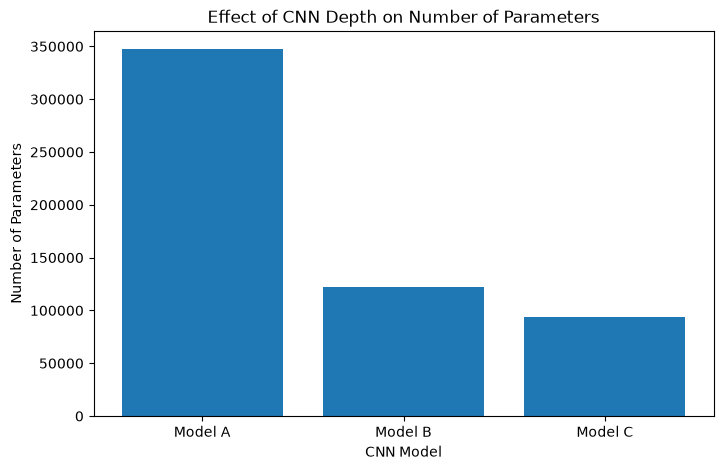

In [83]:
depth_parameters = [
    model_A.count_params(),
    model_B.count_params(),
    model_C.count_params()
]

plt.figure(figsize=(8, 5))

plt.bar(models_names, depth_parameters)

plt.xlabel("CNN Model")
plt.ylabel("Number of Parameters")
plt.title("Effect of CNN Depth on Number of Parameters")

plt.show()

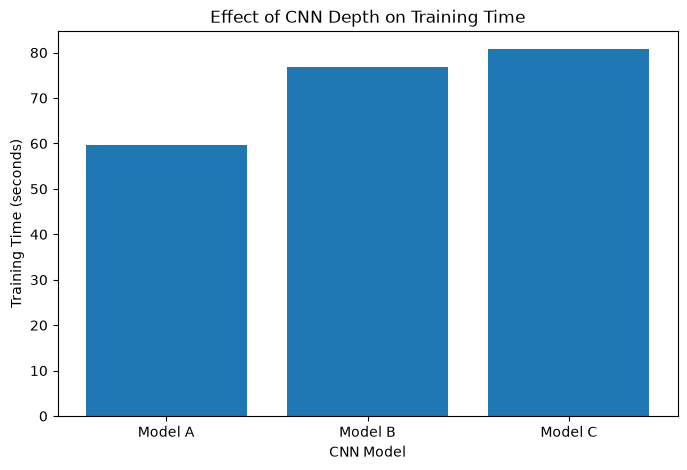

In [84]:
depth_training_times = [
    training_time_A,
    training_time_B,
    training_time_C
]

plt.figure(figsize=(8, 5))

plt.bar(models_names, depth_training_times)

plt.xlabel("CNN Model")
plt.ylabel("Training Time (seconds)")
plt.title("Effect of CNN Depth on Training Time")

plt.show()

1. How does increasing network depth affect classification accuracy?

Increasing the network depth initially improves classification accuracy. In our experiment, Model A with one convolutional layer achieved 98.52% accuracy, while Model B with two convolutional layers achieved the highest accuracy of 99.19%.

However, increasing the depth further did not improve the result. Model C, with three convolutional layers, achieved 98.96%, which was lower than Model B.

Therefore, increasing network depth can improve feature extraction and accuracy up to a certain point, but additional layers do not necessarily provide better performance.

2. Does adding more layers always improve performance?

No, adding more layers does not always improve performance.

In our experiment:

Model A → 98.52%
Model B → 99.19%
Model C → 98.96%

Model B performed better than both Model A and Model C. Although Model C had an additional convolutional layer, its accuracy decreased compared with Model B. It also required the longest training time.

Thus, an unnecessarily deeper network can increase computational cost without improving classification performance.

3. Which model has the best accuracy–complexity trade-off?

Model B provides the best accuracy–complexity trade-off in terms of classification performance.

It achieved the highest test accuracy of 99.19% and the lowest test loss of 0.0303, while requiring 121,930 parameters and only 76.83 seconds of training time.

Although Model C has fewer parameters (93,322), it has lower accuracy (98.96%) and takes slightly longer to train (80.71 seconds). Model A has the shortest training time but requires the most parameters (347,146) and has the lowest accuracy.

Therefore, Model B offers the best balance between accuracy, model complexity, and training time.

# **D. Activation function experiment**
Use activation as
* ReLU
* Leaky ReLU
* ELU


**Answer the following Questions:**

1. Which activation function converges fastest?
2. Which gives the highest validation accuracy?
3. Compare the training and validation loss curves.
4. Does the choice of activation function significantly affect MNIST classification?




In [85]:
model_relu = models.Sequential([
    layers.Conv2D(
        32, (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

In [86]:
model_relu.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [87]:
model_relu.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [88]:
start_time_relu = time.time()

history_relu = model_relu.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

training_time_relu = time.time() - start_time_relu

print("ReLU Training Time:", training_time_relu, "seconds")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9393 - loss: 0.2001 - val_accuracy: 0.9797 - val_loss: 0.0710
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9823 - loss: 0.0554 - val_accuracy: 0.9862 - val_loss: 0.0438
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9884 - loss: 0.0379 - val_accuracy: 0.9892 - val_loss: 0.0353
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9907 - loss: 0.0300 - val_accuracy: 0.9852 - val_loss: 0.0458
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9920 - loss: 0.0245 - val_accuracy: 0.9907 - val_loss: 0.0318
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9938 - loss: 0.0205 - val_accuracy: 0.9888 - val_loss: 0.0376
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9942 - loss: 0.0174 - val_accuracy: 0.9868 - val_loss: 0.0452
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9951 - loss: 0.0151 - val_accuracy: 

In [89]:
test_loss_relu, test_accuracy_relu = model_relu.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("ReLU Test Loss:", test_loss_relu)
print("ReLU Test Accuracy:", test_accuracy_relu)

313/313 - 1s - 4ms/step - accuracy: 0.9919 - loss: 0.0318
ReLU Test Loss: 0.03176044672727585
ReLU Test Accuracy: 0.9919000267982483


In [90]:
model_leaky_relu = models.Sequential([
    layers.Conv2D(
        32, (3, 3),
        input_shape=(28, 28, 1)
    ),
    layers.LeakyReLU(negative_slope=0.01),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3)),
    layers.LeakyReLU(negative_slope=0.01),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3)),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Flatten(),

    layers.Dense(64),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(10)
])

In [91]:
model_leaky_relu.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [92]:
model_leaky_relu.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_27 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [93]:
start_time_leaky_relu = time.time()

history_leaky_relu = model_leaky_relu.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

training_time_leaky_relu = time.time() - start_time_leaky_relu

print(
    "Leaky ReLU Training Time:",
    training_time_leaky_relu,
    "seconds"
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9399 - loss: 0.1961 - val_accuracy: 0.9842 - val_loss: 0.0534
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9834 - loss: 0.0520 - val_accuracy: 0.9847 - val_loss: 0.0502
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9886 - loss: 0.0361 - val_accuracy: 0.9883 - val_loss: 0.0407
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9909 - loss: 0.0286 - val_accuracy: 0.9897 - val_loss: 0.0381
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9927 - loss: 0.0222 - val_accuracy: 0.9893 - val_loss: 0.0373
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9946 - loss: 0.0167 - val_accuracy: 0.9922 - val_loss: 0.0324
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9946 - loss: 0.0168 - val_accuracy: 0.9915 - val_loss: 0.0343
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9962 - loss: 0.0122 - val_accu

In [94]:
test_loss_leaky_relu, test_accuracy_leaky_relu = model_leaky_relu.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("Leaky ReLU Test Loss:", test_loss_leaky_relu)
print("Leaky ReLU Test Accuracy:", test_accuracy_leaky_relu)

313/313 - 1s - 3ms/step - accuracy: 0.9912 - loss: 0.0301
Leaky ReLU Test Loss: 0.030126331374049187
Leaky ReLU Test Accuracy: 0.9911999702453613


In [95]:
model_elu = models.Sequential([
    layers.Conv2D(
        32, (3, 3),
        input_shape=(28, 28, 1)
    ),
    layers.ELU(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3)),
    layers.ELU(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3)),
    layers.ELU(),

    layers.Flatten(),

    layers.Dense(64),
    layers.ELU(),

    layers.Dense(10)
])

In [96]:
model_elu.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [97]:
model_elu.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_30 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ elu (ELU)                       │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ elu_1 (ELU)                     │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ elu_2 (ELU)                     │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ elu_3 (ELU)                     │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [98]:
start_time_elu = time.time()

history_elu = model_elu.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

training_time_elu = time.time() - start_time_elu

print("ELU Training Time:", training_time_elu, "seconds")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9506 - loss: 0.1657 - val_accuracy: 0.9868 - val_loss: 0.0513
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9839 - loss: 0.0520 - val_accuracy: 0.9888 - val_loss: 0.0440
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9892 - loss: 0.0360 - val_accuracy: 0.9898 - val_loss: 0.0408
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9912 - loss: 0.0277 - val_accuracy: 0.9887 - val_loss: 0.0485
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9917 - loss: 0.0249 - val_accuracy: 0.9885 - val_loss: 0.0490
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9935 - loss: 0.0195 - val_accuracy: 0.9853 - val_loss: 0.0606
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9942 - loss: 0.0173 - val_accuracy: 0.9887 - val_loss: 0.0527
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9945 - loss: 0.0164 - val_accuracy:

In [99]:
test_loss_elu, test_accuracy_elu = model_elu.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("ELU Test Loss:", test_loss_elu)
print("ELU Test Accuracy:", test_accuracy_elu)

313/313 - 1s - 3ms/step - accuracy: 0.9898 - loss: 0.0405
ELU Test Loss: 0.04050043970346451
ELU Test Accuracy: 0.989799976348877


In [100]:
print("========== ACTIVATION FUNCTION COMPARISON ==========")

print("\nReLU")
print("Parameters   :", model_relu.count_params())
print("Test Loss    :", test_loss_relu)
print("Test Accuracy:", test_accuracy_relu)
print("Training Time:", training_time_relu, "seconds")

print("\nLeaky ReLU")
print("Parameters   :", model_leaky_relu.count_params())
print("Test Loss    :", test_loss_leaky_relu)
print("Test Accuracy:", test_accuracy_leaky_relu)
print("Training Time:", training_time_leaky_relu, "seconds")

print("\nELU")
print("Parameters   :", model_elu.count_params())
print("Test Loss    :", test_loss_elu)
print("Test Accuracy:", test_accuracy_elu)
print("Training Time:", training_time_elu, "seconds")

========== ACTIVATION FUNCTION COMPARISON ==========

ReLU
Parameters   : 93322
Test Loss    : 0.03176044672727585
Test Accuracy: 0.9919000267982483
Training Time: 78.17043423652649 seconds

Leaky ReLU
Parameters   : 93322
Test Loss    : 0.030126331374049187
Test Accuracy: 0.9911999702453613
Training Time: 84.4113941192627 seconds

ELU
Parameters   : 93322
Test Loss    : 0.04050043970346451
Test Accuracy: 0.989799976348877
Training Time: 81.08815407752991 seconds


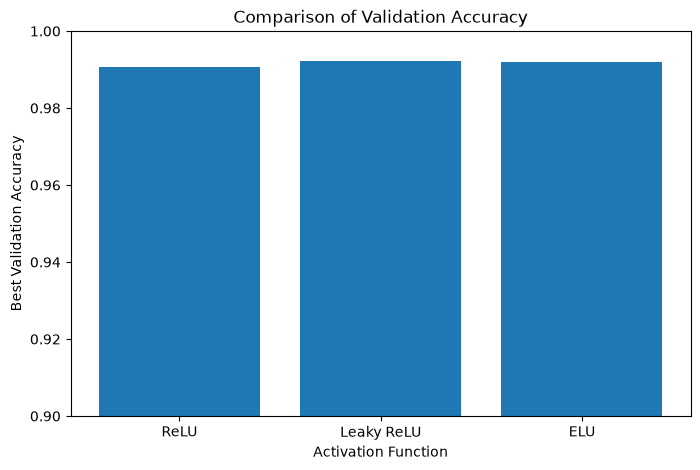

In [101]:
validation_accuracies = [
    max(history_relu.history['val_accuracy']),
    max(history_leaky_relu.history['val_accuracy']),
    max(history_elu.history['val_accuracy'])
]

activation_names = [
    'ReLU',
    'Leaky ReLU',
    'ELU'
]

plt.figure(figsize=(8, 5))

plt.bar(activation_names, validation_accuracies)

plt.xlabel("Activation Function")
plt.ylabel("Best Validation Accuracy")
plt.title("Comparison of Validation Accuracy")

plt.ylim(0.9, 1.0)

plt.show()

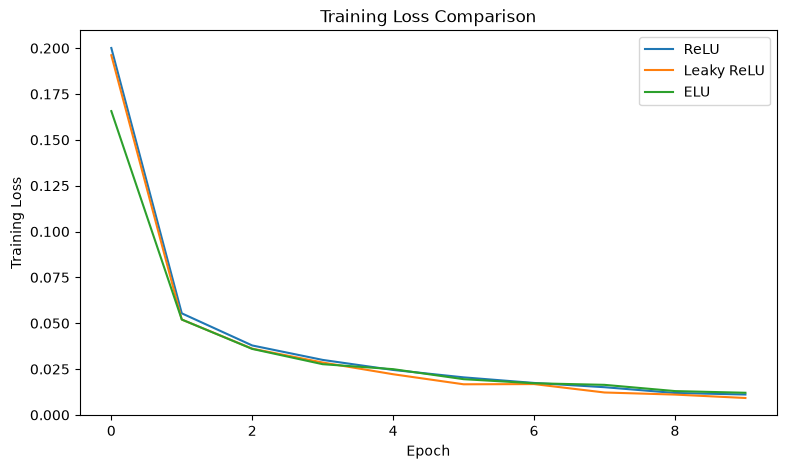

In [102]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_relu.history['loss'],
    label='ReLU'
)

plt.plot(
    history_leaky_relu.history['loss'],
    label='Leaky ReLU'
)

plt.plot(
    history_elu.history['loss'],
    label='ELU'
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Comparison")
plt.legend()

plt.show()

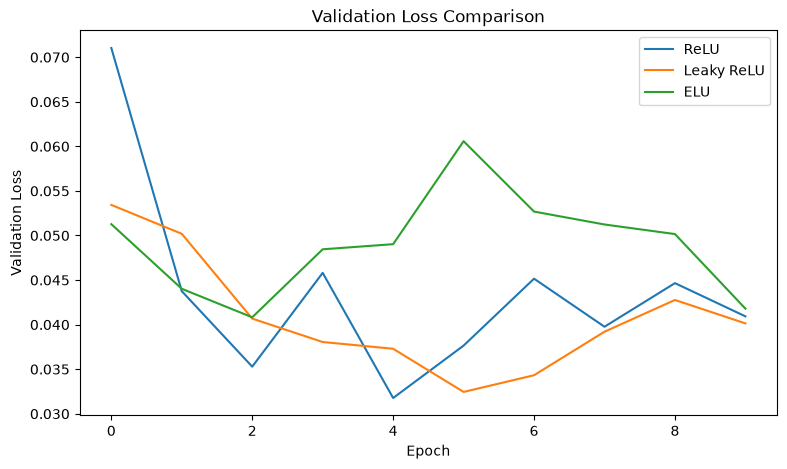

In [103]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_relu.history['val_loss'],
    label='ReLU'
)

plt.plot(
    history_leaky_relu.history['val_loss'],
    label='Leaky ReLU'
)

plt.plot(
    history_elu.history['val_loss'],
    label='ELU'
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.legend()

plt.show()

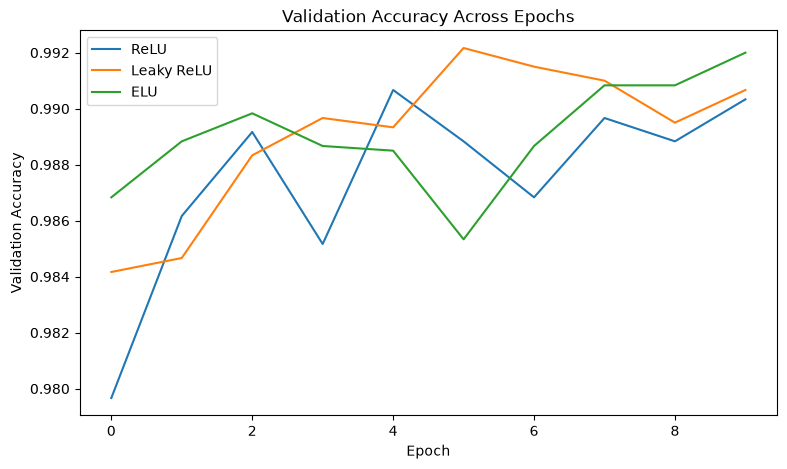

In [104]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_relu.history['val_accuracy'],
    label='ReLU'
)

plt.plot(
    history_leaky_relu.history['val_accuracy'],
    label='Leaky ReLU'
)

plt.plot(
    history_elu.history['val_accuracy'],
    label='ELU'
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Across Epochs")
plt.legend()

plt.show()

In [105]:
print("=" * 70)
print("ACTIVATION FUNCTION DETAILED COMPARISON")
print("=" * 70)

histories = {
    "ReLU": history_relu.history,
    "Leaky ReLU": history_leaky_relu.history,
    "ELU": history_elu.history
}

for name, history in histories.items():

    train_acc = history['accuracy']
    val_acc = history['val_accuracy']
    train_loss = history['loss']
    val_loss = history['val_loss']

    best_val_acc = max(val_acc)
    best_val_epoch = val_acc.index(best_val_acc) + 1

    final_train_acc = train_acc[-1]
    final_val_acc = val_acc[-1]

    final_train_loss = train_loss[-1]
    final_val_loss = val_loss[-1]

    min_val_loss = min(val_loss)
    min_val_loss_epoch = val_loss.index(min_val_loss) + 1

    print(f"\n{name}")
    print("-" * 50)
    print(f"Best Validation Accuracy : {best_val_acc:.6f} "
          f"(Epoch {best_val_epoch})")
    print(f"Final Training Accuracy  : {final_train_acc:.6f}")
    print(f"Final Validation Accuracy: {final_val_acc:.6f}")
    print(f"Final Training Loss      : {final_train_loss:.6f}")
    print(f"Final Validation Loss    : {final_val_loss:.6f}")
    print(f"Minimum Validation Loss  : {min_val_loss:.6f} "
          f"(Epoch {min_val_loss_epoch})")

print("\n" + "=" * 70)
print("EPOCH-WISE VALIDATION ACCURACY")
print("=" * 70)

print(f"{'Epoch':<8}{'ReLU':<15}{'Leaky ReLU':<15}{'ELU':<15}")

for i in range(10):
    print(
        f"{i+1:<8}"
        f"{history_relu.history['val_accuracy'][i]:<15.6f}"
        f"{history_leaky_relu.history['val_accuracy'][i]:<15.6f}"
        f"{history_elu.history['val_accuracy'][i]:<15.6f}"
    )

print("\n" + "=" * 70)
print("EPOCH-WISE VALIDATION LOSS")
print("=" * 70)

print(f"{'Epoch':<8}{'ReLU':<15}{'Leaky ReLU':<15}{'ELU':<15}")

for i in range(10):
    print(
        f"{i+1:<8}"
        f"{history_relu.history['val_loss'][i]:<15.6f}"
        f"{history_leaky_relu.history['val_loss'][i]:<15.6f}"
        f"{history_elu.history['val_loss'][i]:<15.6f}"
    )

ACTIVATION FUNCTION DETAILED COMPARISON

ReLU
--------------------------------------------------
Best Validation Accuracy : 0.990667 (Epoch 5)
Final Training Accuracy  : 0.996704
Final Validation Accuracy: 0.990333
Final Training Loss      : 0.011120
Final Validation Loss    : 0.040929
Minimum Validation Loss  : 0.031769 (Epoch 5)

Leaky ReLU
--------------------------------------------------
Best Validation Accuracy : 0.992167 (Epoch 6)
Final Training Accuracy  : 0.996907
Final Validation Accuracy: 0.990667
Final Training Loss      : 0.009221
Final Validation Loss    : 0.040138
Minimum Validation Loss  : 0.032449 (Epoch 6)

ELU
--------------------------------------------------
Best Validation Accuracy : 0.992000 (Epoch 10)
Final Training Accuracy  : 0.996111
Final Validation Accuracy: 0.992000
Final Training Loss      : 0.012071
Final Validation Loss    : 0.041793
Minimum Validation Loss  : 0.040824 (Epoch 3)

EPOCH-WISE VALIDATION ACCURACY
Epoch   ReLU           Leaky ReLU     ELU  

Answers to Questions
1. Which activation function converges fastest?

ReLU converges fastest in our experiment. It reached its best validation accuracy of 99.07% at Epoch 5, while Leaky ReLU reached its best validation accuracy at Epoch 6 and ELU reached its best at Epoch 10.

Therefore, ReLU reached a high validation accuracy slightly earlier than the other activation functions.

2. Which gives the highest validation accuracy?

Leaky ReLU gives the highest validation accuracy.

The best validation accuracies were:

ReLU: 99.07%
Leaky ReLU: 99.22%
ELU: 99.20%

Thus, Leaky ReLU achieved the highest validation accuracy of 99.22%.

3. Compare the training and validation loss curves.

For all three activation functions, the training loss decreases as the epochs increase, showing that the models are learning the training data.

However, the validation loss does not continuously decrease. After reaching a minimum, it fluctuates or increases while training loss continues to decrease. This indicates some overfitting.

For example, ReLU reached its minimum validation loss at Epoch 5, while its training loss continued decreasing afterward. A similar pattern was observed for Leaky ReLU and ELU.

Therefore, the training and validation loss curves show good learning initially, followed by some overfitting in the later epochs.

4. Does the choice of activation function significantly affect MNIST classification?

The choice of activation function has some effect, but it is not very significant for MNIST classification in this experiment.

The test accuracies were:

ReLU: 99.19%
Leaky ReLU: 99.12%
ELU: 98.98%

All three achieved approximately 99% test accuracy. Leaky ReLU had the highest validation accuracy, while ReLU had the highest test accuracy and the shortest training time.

Therefore, although the activation function affects convergence, validation accuracy, and loss, all three activation functions perform very well on MNIST, and the overall difference in classification accuracy is small.

# **E. Optimizer Comparison**

Train the same architecture using:

* Adam
* SGD
* RMSprop

**Answer the following Questions:**

1. Which optimizer converges fastest?
2. Which gives the best final accuracy?
3. Which training curve is most stable?
4. How does learning rate affect each optimizer?


In [106]:
model_adam = models.Sequential([
    layers.Conv2D(
        32, (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

In [107]:
model_adam.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [108]:
start_time_adam = time.time()

history_adam = model_adam.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

training_time_adam = time.time() - start_time_adam

print("Adam Training Time:", training_time_adam, "seconds")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9396 - loss: 0.1974 - val_accuracy: 0.9825 - val_loss: 0.0656
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9829 - loss: 0.0545 - val_accuracy: 0.9873 - val_loss: 0.0450
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9878 - loss: 0.0381 - val_accuracy: 0.9890 - val_loss: 0.0409
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9906 - loss: 0.0304 - val_accuracy: 0.9902 - val_loss: 0.0351
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9926 - loss: 0.0236 - val_accuracy: 0.9892 - val_loss: 0.0371
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9936 - loss: 0.0202 - val_accuracy: 0.9917 - val_loss: 0.0292
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9946 - loss: 0.0168 - val_accuracy: 0.9905 - val_loss: 0.0315
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9956 - loss: 0.0135 - val_accuracy: 

In [109]:
test_loss_adam, test_accuracy_adam = model_adam.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("Adam Test Loss:", test_loss_adam)
print("Adam Test Accuracy:", test_accuracy_adam)

313/313 - 1s - 2ms/step - accuracy: 0.9913 - loss: 0.0325
Adam Test Loss: 0.032507944852113724
Adam Test Accuracy: 0.9912999868392944


In [110]:
model_sgd = models.Sequential([
    layers.Conv2D(
        32, (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

In [111]:
model_sgd.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [112]:
start_time_sgd = time.time()

history_sgd = model_sgd.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

training_time_sgd = time.time() - start_time_sgd

print("SGD Training Time:", training_time_sgd, "seconds")


Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.7436 - loss: 0.8789 - val_accuracy: 0.9302 - val_loss: 0.2379
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9292 - loss: 0.2308 - val_accuracy: 0.9565 - val_loss: 0.1507
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9533 - loss: 0.1523 - val_accuracy: 0.9728 - val_loss: 0.0988
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9639 - loss: 0.1182 - val_accuracy: 0.9762 - val_loss: 0.0827
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9700 - loss: 0.0972 - val_accuracy: 0.9775 - val_loss: 0.0791
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9740 - loss: 0.0838 - val_accuracy: 0.9802 - val_loss: 0.0687
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9769 - loss: 0.0744 - val_accuracy: 0.9818 - val_loss: 0.0676
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9781 - loss: 0.0683 - val_accuracy: 0.

In [113]:
test_loss_sgd, test_accuracy_sgd = model_sgd.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("SGD Test Loss:", test_loss_sgd)
print("SGD Test Accuracy:", test_accuracy_sgd)

313/313 - 1s - 2ms/step - accuracy: 0.9842 - loss: 0.0513
SGD Test Loss: 0.05129840597510338
SGD Test Accuracy: 0.9842000007629395


In [114]:
model_rmsprop = models.Sequential([
    layers.Conv2D(
        32, (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

In [115]:
model_rmsprop.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [116]:
start_time_rmsprop = time.time()

history_rmsprop = model_rmsprop.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

training_time_rmsprop = time.time() - start_time_rmsprop

print("RMSprop Training Time:", training_time_rmsprop, "seconds")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9395 - loss: 0.1890 - val_accuracy: 0.9760 - val_loss: 0.0756
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9846 - loss: 0.0495 - val_accuracy: 0.9907 - val_loss: 0.0386
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9891 - loss: 0.0340 - val_accuracy: 0.9913 - val_loss: 0.0330
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9922 - loss: 0.0256 - val_accuracy: 0.9903 - val_loss: 0.0372
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9932 - loss: 0.0205 - val_accuracy: 0.9907 - val_loss: 0.0352
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9951 - loss: 0.0152 - val_accuracy: 0.9922 - val_loss: 0.0339
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9961 - loss: 0.0128 - val_accuracy: 0.9900 - val_loss: 0.0423
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9967 - loss: 0.0101 - val_accuracy: 0.

In [117]:
test_loss_rmsprop, test_accuracy_rmsprop = model_rmsprop.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("RMSprop Test Loss:", test_loss_rmsprop)
print("RMSprop Test Accuracy:", test_accuracy_rmsprop)

313/313 - 1s - 2ms/step - accuracy: 0.9931 - loss: 0.0321
RMSprop Test Loss: 0.03210025280714035
RMSprop Test Accuracy: 0.9930999875068665


In [118]:
print("========== OPTIMIZER COMPARISON ==========")

print("\nAdam")
print("Parameters   :", model_adam.count_params())
print("Test Loss    :", test_loss_adam)
print("Test Accuracy:", test_accuracy_adam)
print("Training Time:", training_time_adam, "seconds")

print("\nSGD")
print("Parameters   :", model_sgd.count_params())
print("Test Loss    :", test_loss_sgd)
print("Test Accuracy:", test_accuracy_sgd)
print("Training Time:", training_time_sgd, "seconds")

print("\nRMSprop")
print("Parameters   :", model_rmsprop.count_params())
print("Test Loss    :", test_loss_rmsprop)
print("Test Accuracy:", test_accuracy_rmsprop)
print("Training Time:", training_time_rmsprop, "seconds")

========== OPTIMIZER COMPARISON ==========

Adam
Parameters   : 93322
Test Loss    : 0.032507944852113724
Test Accuracy: 0.9912999868392944
Training Time: 76.46222472190857 seconds

SGD
Parameters   : 93322
Test Loss    : 0.05129840597510338
Test Accuracy: 0.9842000007629395
Training Time: 71.36125636100769 seconds

RMSprop
Parameters   : 93322
Test Loss    : 0.03210025280714035
Test Accuracy: 0.9930999875068665
Training Time: 65.94382643699646 seconds


In [119]:
best_val_acc_adam = max(history_adam.history['val_accuracy'])
best_val_acc_sgd = max(history_sgd.history['val_accuracy'])
best_val_acc_rmsprop = max(history_rmsprop.history['val_accuracy'])

print("========== BEST VALIDATION ACCURACY ==========")

print("Adam   :", best_val_acc_adam)
print("SGD    :", best_val_acc_sgd)
print("RMSprop:", best_val_acc_rmsprop)

========== BEST VALIDATION ACCURACY ==========
Adam   : 0.9923333525657654
SGD    : 0.984000027179718
RMSprop: 0.9923333525657654


In [120]:
print("=" * 75)
print("OPTIMIZER CONVERGENCE ANALYSIS")
print("=" * 75)

optimizer_histories = {
    "Adam": history_adam.history,
    "SGD": history_sgd.history,
    "RMSprop": history_rmsprop.history
}

for name, history in optimizer_histories.items():

    train_acc = history['accuracy']
    val_acc = history['val_accuracy']
    train_loss = history['loss']
    val_loss = history['val_loss']

    best_val_acc = max(val_acc)
    best_val_epoch = val_acc.index(best_val_acc) + 1

    min_val_loss = min(val_loss)
    min_val_loss_epoch = val_loss.index(min_val_loss) + 1

    print(f"\n{name}")
    print("-" * 55)
    print(f"Best Validation Accuracy : {best_val_acc:.6f}")
    print(f"Best Validation Epoch    : {best_val_epoch}")
    print(f"Minimum Validation Loss  : {min_val_loss:.6f}")
    print(f"Minimum Loss Epoch       : {min_val_loss_epoch}")
    print(f"Final Training Accuracy  : {train_acc[-1]:.6f}")
    print(f"Final Validation Accuracy: {val_acc[-1]:.6f}")
    print(f"Final Training Loss      : {train_loss[-1]:.6f}")
    print(f"Final Validation Loss    : {val_loss[-1]:.6f}")

print("\n" + "=" * 75)
print("EPOCH-WISE VALIDATION ACCURACY")
print("=" * 75)

print(f"{'Epoch':<8}{'Adam':<15}{'SGD':<15}{'RMSprop':<15}")

for i in range(10):
    print(
        f"{i+1:<8}"
        f"{history_adam.history['val_accuracy'][i]:<15.6f}"
        f"{history_sgd.history['val_accuracy'][i]:<15.6f}"
        f"{history_rmsprop.history['val_accuracy'][i]:<15.6f}"
    )

print("\n" + "=" * 75)
print("EPOCH-WISE VALIDATION LOSS")
print("=" * 75)

print(f"{'Epoch':<8}{'Adam':<15}{'SGD':<15}{'RMSprop':<15}")

for i in range(10):
    print(
        f"{i+1:<8}"
        f"{history_adam.history['val_loss'][i]:<15.6f}"
        f"{history_sgd.history['val_loss'][i]:<15.6f}"
        f"{history_rmsprop.history['val_loss'][i]:<15.6f}"
    )

OPTIMIZER CONVERGENCE ANALYSIS

Adam
-------------------------------------------------------
Best Validation Accuracy : 0.992333
Best Validation Epoch    : 9
Minimum Validation Loss  : 0.029239
Minimum Loss Epoch       : 6
Final Training Accuracy  : 0.996982
Final Validation Accuracy: 0.992000
Final Training Loss      : 0.009568
Final Validation Loss    : 0.036346

SGD
-------------------------------------------------------
Best Validation Accuracy : 0.984000
Best Validation Epoch    : 9
Minimum Validation Loss  : 0.057769
Minimum Loss Epoch       : 10
Final Training Accuracy  : 0.982019
Final Validation Accuracy: 0.984000
Final Training Loss      : 0.057559
Final Validation Loss    : 0.057769

RMSprop
-------------------------------------------------------
Best Validation Accuracy : 0.992333
Best Validation Epoch    : 10
Minimum Validation Loss  : 0.032955
Minimum Loss Epoch       : 3
Final Training Accuracy  : 0.997833
Final Validation Accuracy: 0.992333
Final Training Loss      : 0.

1. Which optimizer converges fastest?

Based on the validation accuracy and loss progression, RMSprop shows the fastest early convergence. It reached 99.07% validation accuracy by Epoch 2 and achieved its minimum validation loss of 0.03296 at Epoch 3.

Adam also converged quickly, reaching 98.25% validation accuracy in Epoch 1 and a minimum validation loss of 0.02924 at Epoch 6.

SGD converged more slowly, starting at only 93.02% validation accuracy in Epoch 1 and gradually reaching 98.40% by Epoch 9.

Therefore, RMSprop demonstrated the fastest early convergence, while SGD was the slowest.

2. Which optimizer achieves the highest final accuracy?

RMSprop achieved the highest test accuracy.

The final test accuracies were:

Adam: 99.13%
SGD: 98.42%
RMSprop: 99.31%

Therefore, RMSprop performed best on the test set with an accuracy of 99.31%.

3. How does optimizer choice affect training stability?

Optimizer choice significantly affected the training behavior.

Adam showed relatively stable convergence, with validation accuracy generally remaining around 98.9–99.2% after the first few epochs.

SGD showed slower but steady improvement. Its validation accuracy increased gradually from 93.02% to 98.40%, but it did not reach the accuracy achieved by Adam or RMSprop within 10 epochs.

RMSprop converged very quickly, but its validation loss became less stable after reaching its minimum at Epoch 3. It increased from 0.03296 at Epoch 3 to 0.05307 at Epoch 10, even though validation accuracy remained high.

Thus, Adam provided relatively stable training, RMSprop provided fast convergence and high accuracy, while SGD required more epochs to reach comparable performance.

4. What is the effect of learning rate on convergence?

The learning rate controls the size of the updates made to the model weights during training. A suitable learning rate allows the model to converge efficiently, while an inappropriate learning rate can make training too slow or unstable.

In this experiment, Adam and RMSprop used a learning rate of 0.001, while SGD used 0.01. Despite SGD having the larger learning rate, it converged more slowly and achieved lower accuracy.

This shows that the learning rate cannot be considered independently of the optimizer. Different optimizers respond differently to the same learning-rate scale. A suitable combination of optimizer and learning rate is therefore important for achieving fast and stable convergence.

# **F. Learning rate experiment**

For adam choose LR as 0.1,     0.01,     0.001,      0.0001

**Answer the following Questions:**

1. What happens when the learning rate is too high?
2. What happens when it is too low?
3. Which learning rate gives the fastest convergence?
4. Plot and compare training/validation accuracy for all experiments.

In [121]:
model_lr_01 = models.Sequential([
    layers.Conv2D(
        32, (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

In [122]:
model_lr_01.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [123]:
start_time_lr_01 = time.time()

history_lr_01 = model_lr_01.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

training_time_lr_01 = time.time() - start_time_lr_01

print("LR 0.1 Training Time:", training_time_lr_01, "seconds")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.1051 - loss: 3.2303 - val_accuracy: 0.1045 - val_loss: 2.3171
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.1040 - loss: 2.3096 - val_accuracy: 0.0952 - val_loss: 2.3107
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.1049 - loss: 2.3098 - val_accuracy: 0.1000 - val_loss: 2.3114
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.1052 - loss: 2.3103 - val_accuracy: 0.1045 - val_loss: 2.3148
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.1036 - loss: 2.3106 - val_accuracy: 0.0960 - val_loss: 2.3198
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.1051 - loss: 2.3100 - val_accuracy: 0.1113 - val_loss: 2.3122
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.1036 - loss: 2.3095 - val_accuracy: 0.1050 - val_loss: 2.3091
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.1026 - loss: 2.3111 - val_accuracy: 0

In [124]:
test_loss_lr_01, test_accuracy_lr_01 = model_lr_01.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("LR 0.1 Test Loss:", test_loss_lr_01)
print("LR 0.1 Test Accuracy:", test_accuracy_lr_01)

313/313 - 1s - 3ms/step - accuracy: 0.1010 - loss: 2.3117
LR 0.1 Test Loss: 2.311680555343628
LR 0.1 Test Accuracy: 0.10100000351667404


In [125]:
model_lr_001 = models.Sequential([
    layers.Conv2D(
        32, (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

In [126]:
model_lr_001.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [127]:
start_time_lr_001 = time.time()

history_lr_001 = model_lr_001.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

training_time_lr_001 = time.time() - start_time_lr_001

print("LR 0.01 Training Time:", training_time_lr_001, "seconds")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9370 - loss: 0.1962 - val_accuracy: 0.9780 - val_loss: 0.0730
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9736 - loss: 0.0855 - val_accuracy: 0.9788 - val_loss: 0.0771
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9775 - loss: 0.0797 - val_accuracy: 0.9762 - val_loss: 0.0813
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9787 - loss: 0.0727 - val_accuracy: 0.9748 - val_loss: 0.1013
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9795 - loss: 0.0696 - val_accuracy: 0.9798 - val_loss: 0.0647
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9810 - loss: 0.0681 - val_accuracy: 0.9815 - val_loss: 0.0697
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9802 - loss: 0.0695 - val_accuracy: 0.9770 - val_loss: 0.0930
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9808 - loss: 0.0704 - val_accuracy: 

In [128]:
test_loss_lr_001, test_accuracy_lr_001 = model_lr_001.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("LR 0.01 Test Loss:", test_loss_lr_001)
print("LR 0.01 Test Accuracy:", test_accuracy_lr_001)

313/313 - 1s - 3ms/step - accuracy: 0.9717 - loss: 0.1079
LR 0.01 Test Loss: 0.10785236954689026
LR 0.01 Test Accuracy: 0.9717000126838684


In [129]:
model_lr_0001 = models.Sequential([
    layers.Conv2D(
        32, (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

In [131]:
model_lr_0001.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [132]:
start_time_lr_0001 = time.time()

history_lr_0001 = model_lr_0001.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

training_time_lr_0001 = time.time() - start_time_lr_0001

print("LR 0.001 Training Time:", training_time_lr_0001, "seconds")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9391 - loss: 0.1996 - val_accuracy: 0.9813 - val_loss: 0.0622
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9839 - loss: 0.0519 - val_accuracy: 0.9885 - val_loss: 0.0389
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9878 - loss: 0.0379 - val_accuracy: 0.9885 - val_loss: 0.0409
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9911 - loss: 0.0284 - val_accuracy: 0.9900 - val_loss: 0.0386
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9926 - loss: 0.0231 - val_accuracy: 0.9898 - val_loss: 0.0327
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9937 - loss: 0.0195 - val_accuracy: 0.9903 - val_loss: 0.0340
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9949 - loss: 0.0153 - val_accuracy: 0.9912 - val_loss: 0.0341
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9955 - loss: 0.0141 - val_accuracy: 0.

In [133]:
test_loss_lr_0001, test_accuracy_lr_0001 = model_lr_0001.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("LR 0.001 Test Loss:", test_loss_lr_0001)
print("LR 0.001 Test Accuracy:", test_accuracy_lr_0001)

313/313 - 1s - 2ms/step - accuracy: 0.9922 - loss: 0.0284
LR 0.001 Test Loss: 0.02842104248702526
LR 0.001 Test Accuracy: 0.9922000169754028


In [134]:
model_lr_00001 = models.Sequential([
    layers.Conv2D(
        32, (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

In [135]:
model_lr_00001.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [136]:
start_time_lr_00001 = time.time()

history_lr_00001 = model_lr_00001.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

training_time_lr_00001 = time.time() - start_time_lr_00001

print("LR 0.0001 Training Time:", training_time_lr_00001, "seconds")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8305 - loss: 0.6096 - val_accuracy: 0.9563 - val_loss: 0.1633
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9529 - loss: 0.1620 - val_accuracy: 0.9737 - val_loss: 0.1016
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9660 - loss: 0.1123 - val_accuracy: 0.9772 - val_loss: 0.0831
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9730 - loss: 0.0905 - val_accuracy: 0.9802 - val_loss: 0.0712
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9776 - loss: 0.0758 - val_accuracy: 0.9790 - val_loss: 0.0743
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9802 - loss: 0.0670 - val_accuracy: 0.9825 - val_loss: 0.0612
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9821 - loss: 0.0589 - val_accuracy: 0.9872 - val_loss: 0.0507
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9839 - loss: 0.0544 - val_accuracy: 0.

In [137]:
test_loss_lr_00001, test_accuracy_lr_00001 = model_lr_00001.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("LR 0.0001 Test Loss:", test_loss_lr_00001)
print("LR 0.0001 Test Accuracy:", test_accuracy_lr_00001)

313/313 - 1s - 2ms/step - accuracy: 0.9881 - loss: 0.0389
LR 0.0001 Test Loss: 0.03888528421521187
LR 0.0001 Test Accuracy: 0.988099992275238


In [138]:
print("========== LEARNING RATE COMPARISON ==========")

print("\nLearning Rate = 0.1")
print("Test Loss    :", test_loss_lr_01)
print("Test Accuracy:", test_accuracy_lr_01)
print("Training Time:", training_time_lr_01, "seconds")

print("\nLearning Rate = 0.01")
print("Test Loss    :", test_loss_lr_001)
print("Test Accuracy:", test_accuracy_lr_001)
print("Training Time:", training_time_lr_001, "seconds")

print("\nLearning Rate = 0.001")
print("Test Loss    :", test_loss_lr_0001)
print("Test Accuracy:", test_accuracy_lr_0001)
print("Training Time:", training_time_lr_0001, "seconds")

print("\nLearning Rate = 0.0001")
print("Test Loss    :", test_loss_lr_00001)
print("Test Accuracy:", test_accuracy_lr_00001)
print("Training Time:", training_time_lr_00001, "seconds")

========== LEARNING RATE COMPARISON ==========

Learning Rate = 0.1
Test Loss    : 2.311680555343628
Test Accuracy: 0.10100000351667404
Training Time: 77.28255891799927 seconds

Learning Rate = 0.01
Test Loss    : 0.10785236954689026
Test Accuracy: 0.9717000126838684
Training Time: 72.46094608306885 seconds

Learning Rate = 0.001
Test Loss    : 0.02842104248702526
Test Accuracy: 0.9922000169754028
Training Time: 61.01604723930359 seconds

Learning Rate = 0.0001
Test Loss    : 0.03888528421521187
Test Accuracy: 0.988099992275238
Training Time: 59.01416730880737 seconds


In [139]:
print("=" * 80)
print("LEARNING RATE CONVERGENCE ANALYSIS")
print("=" * 80)

lr_histories = {
    "0.1": history_lr_01.history,
    "0.01": history_lr_001.history,
    "0.001": history_lr_0001.history,
    "0.0001": history_lr_00001.history
}

for lr, history in lr_histories.items():

    train_acc = history['accuracy']
    val_acc = history['val_accuracy']
    train_loss = history['loss']
    val_loss = history['val_loss']

    best_train_acc = max(train_acc)
    best_val_acc = max(val_acc)

    best_val_epoch = val_acc.index(best_val_acc) + 1

    min_train_loss = min(train_loss)
    min_val_loss = min(val_loss)

    min_val_loss_epoch = val_loss.index(min_val_loss) + 1

    print(f"\nLearning Rate = {lr}")
    print("-" * 55)

    print(f"Best Training Accuracy  : {best_train_acc:.6f}")
    print(f"Best Validation Accuracy: {best_val_acc:.6f}")
    print(f"Best Validation Epoch   : {best_val_epoch}")

    print(f"Minimum Training Loss   : {min_train_loss:.6f}")
    print(f"Minimum Validation Loss : {min_val_loss:.6f}")
    print(f"Minimum Loss Epoch      : {min_val_loss_epoch}")

    print(f"Final Training Accuracy : {train_acc[-1]:.6f}")
    print(f"Final Validation Accuracy: {val_acc[-1]:.6f}")
    print(f"Final Training Loss     : {train_loss[-1]:.6f}")
    print(f"Final Validation Loss   : {val_loss[-1]:.6f}")

print("\n" + "=" * 80)
print("EPOCH-WISE TRAINING ACCURACY")
print("=" * 80)

print(
    f"{'Epoch':<8}"
    f"{'LR 0.1':<15}"
    f"{'LR 0.01':<15}"
    f"{'LR 0.001':<15}"
    f"{'LR 0.0001':<15}"
)

for i in range(10):
    print(
        f"{i+1:<8}"
        f"{history_lr_01.history['accuracy'][i]:<15.6f}"
        f"{history_lr_001.history['accuracy'][i]:<15.6f}"
        f"{history_lr_0001.history['accuracy'][i]:<15.6f}"
        f"{history_lr_00001.history['accuracy'][i]:<15.6f}"
    )

print("\n" + "=" * 80)
print("EPOCH-WISE VALIDATION ACCURACY")
print("=" * 80)

print(
    f"{'Epoch':<8}"
    f"{'LR 0.1':<15}"
    f"{'LR 0.01':<15}"
    f"{'LR 0.001':<15}"
    f"{'LR 0.0001':<15}"
)

for i in range(10):
    print(
        f"{i+1:<8}"
        f"{history_lr_01.history['val_accuracy'][i]:<15.6f}"
        f"{history_lr_001.history['val_accuracy'][i]:<15.6f}"
        f"{history_lr_0001.history['val_accuracy'][i]:<15.6f}"
        f"{history_lr_00001.history['val_accuracy'][i]:<15.6f}"
    )

LEARNING RATE CONVERGENCE ANALYSIS

Learning Rate = 0.1
-------------------------------------------------------
Best Training Accuracy  : 0.105222
Best Validation Accuracy: 0.111333
Best Validation Epoch   : 6
Minimum Training Loss   : 2.309438
Minimum Validation Loss : 2.309103
Minimum Loss Epoch      : 7
Final Training Accuracy : 0.104481
Final Validation Accuracy: 0.104500
Final Training Loss     : 2.309859
Final Validation Loss   : 2.311020

Learning Rate = 0.01
-------------------------------------------------------
Best Training Accuracy  : 0.982944
Best Validation Accuracy: 0.981500
Best Validation Epoch   : 6
Minimum Training Loss   : 0.063226
Minimum Validation Loss : 0.064694
Minimum Loss Epoch      : 5
Final Training Accuracy : 0.982944
Final Validation Accuracy: 0.974500
Final Training Loss     : 0.063226
Final Validation Loss   : 0.104509

Learning Rate = 0.001
-------------------------------------------------------
Best Training Accuracy  : 0.996481
Best Validation Accura

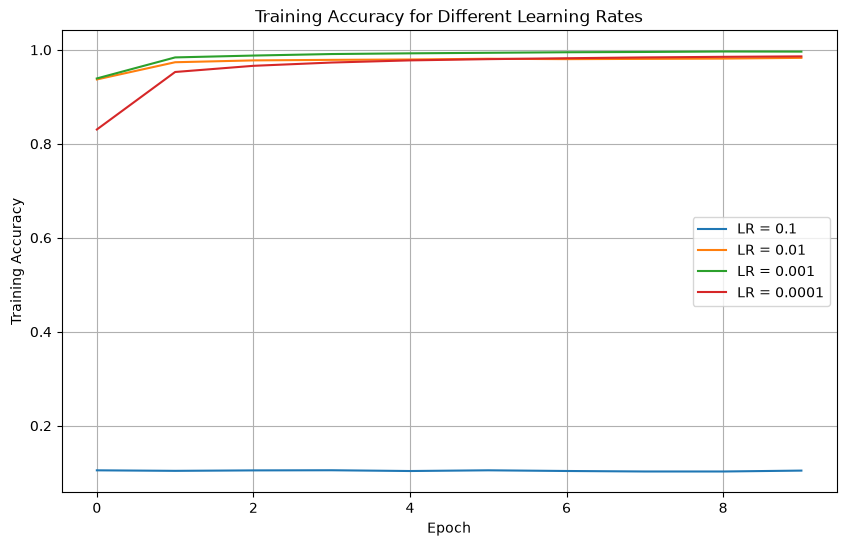

In [140]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_lr_01.history['accuracy'],
    label='LR = 0.1'
)

plt.plot(
    history_lr_001.history['accuracy'],
    label='LR = 0.01'
)

plt.plot(
    history_lr_0001.history['accuracy'],
    label='LR = 0.001'
)

plt.plot(
    history_lr_00001.history['accuracy'],
    label='LR = 0.0001'
)

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy for Different Learning Rates")
plt.legend()
plt.grid(True)

plt.show()

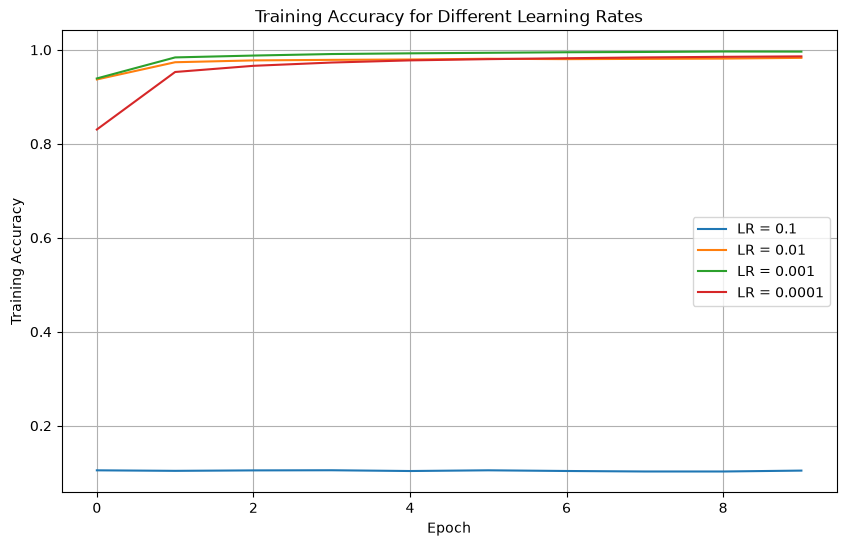

In [141]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_lr_01.history['accuracy'],
    label='LR = 0.1'
)

plt.plot(
    history_lr_001.history['accuracy'],
    label='LR = 0.01'
)

plt.plot(
    history_lr_0001.history['accuracy'],
    label='LR = 0.001'
)

plt.plot(
    history_lr_00001.history['accuracy'],
    label='LR = 0.0001'
)

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy for Different Learning Rates")
plt.legend()
plt.grid(True)

plt.show()

1. What happens when the learning rate is too high?

When the learning rate is too high, the model makes excessively large updates to its weights and fails to converge properly.

In our experiment, a learning rate of 0.1 resulted in only 10.10% test accuracy, which is close to random guessing for the 10-class MNIST problem. The training and validation accuracy remained around 10%, while the loss stayed around 2.31.

Therefore, a very high learning rate can cause the optimization process to overshoot the minimum repeatedly, preventing the model from learning effectively.

2. What happens when the learning rate is too low?

When the learning rate is too low, the model makes very small updates to its weights. This makes learning slower and can prevent the model from reaching the best solution within the available number of epochs.

In our experiment, the learning rate 0.0001 achieved 98.81% test accuracy, which is good, but lower than the 99.22% achieved using 0.001.

Therefore, a very low learning rate can result in slow convergence and insufficient learning within the given 10 epochs.

3. Which learning rate gives the fastest convergence?

The learning rate 0.001 gives the best and fastest convergence in our experiment.

It achieved:

99.22% test accuracy
0.0284 test loss
Best validation accuracy of approximately 99.28%
Training time of 61.02 seconds

The learning rate of 0.01 also learned reasonably well, but its final accuracy was considerably lower at 97.17%. The learning rate of 0.1 failed to converge effectively, while 0.0001 learned more slowly.

Therefore, 0.001 provides the best balance between convergence speed and final accuracy.

4. Plot and compare training/validation accuracy for all experiments.

The training and validation accuracy curves show a clear effect of the learning rate.

LR = 0.1: Accuracy remains around 10%, showing that the model fails to learn.
LR = 0.01: Accuracy increases rapidly and reaches around 97–98%, but does not achieve the performance of 0.001.
LR = 0.001: Accuracy increases quickly and reaches approximately 99%, giving the best overall performance.
LR = 0.0001: Accuracy improves more gradually and reaches around 98–99%, but convergence is slower.

Overall, the experiment demonstrates that the learning rate must be chosen carefully. A learning rate that is too high prevents convergence, while one that is too low slows learning. In this experiment, 0.001 was the most suitable learning rate for Adam.

# **G. Batch size experiment**

**Compare:**

* Batch size = 32
* Batch size = 64
* Batch size = 128
* Batch size = 256

**Answer the following Questions:**

1. How does batch size affect training time?
2. How does it affect convergence?
3. Which batch size gives the best validation accuracy?
4. Is the largest batch size necessarily the best?

In [142]:
model_bs_32 = models.Sequential([
    layers.Conv2D(
        32, (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

In [143]:
model_bs_32.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [144]:
start_time_bs_32 = time.time()

history_bs_32 = model_bs_32.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=32
)

training_time_bs_32 = time.time() - start_time_bs_32

print("Batch Size 32 Training Time:", training_time_bs_32, "seconds")

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9492 - loss: 0.1608 - val_accuracy: 0.9838 - val_loss: 0.0573
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9833 - loss: 0.0514 - val_accuracy: 0.9855 - val_loss: 0.0516
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9878 - loss: 0.0371 - val_accuracy: 0.9897 - val_loss: 0.0368
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9913 - loss: 0.0274 - val_accuracy: 0.9897 - val_loss: 0.0345
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9926 - loss: 0.0231 - val_accuracy: 0.9900 - val_loss: 0.0338
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9939 - loss: 0.0188 - val_accuracy: 0.9888 - val_loss: 0.0408
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9949 - loss: 0.0153 - val_accuracy: 0.9917 - val_loss: 0.0389
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9959 - loss: 0

In [145]:
test_loss_bs_32, test_accuracy_bs_32 = model_bs_32.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("Batch Size 32 Test Loss:", test_loss_bs_32)
print("Batch Size 32 Test Accuracy:", test_accuracy_bs_32)

313/313 - 1s - 3ms/step - accuracy: 0.9897 - loss: 0.0388
Batch Size 32 Test Loss: 0.038750581443309784
Batch Size 32 Test Accuracy: 0.9897000193595886


In [146]:
model_bs_64 = models.Sequential([
    layers.Conv2D(
        32, (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

In [147]:
model_bs_64.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [148]:
start_time_bs_64 = time.time()

history_bs_64 = model_bs_64.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

training_time_bs_64 = time.time() - start_time_bs_64

print("Batch Size 64 Training Time:", training_time_bs_64, "seconds")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9389 - loss: 0.2028 - val_accuracy: 0.9845 - val_loss: 0.0570
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9822 - loss: 0.0577 - val_accuracy: 0.9893 - val_loss: 0.0379
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9880 - loss: 0.0382 - val_accuracy: 0.9873 - val_loss: 0.0469
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9904 - loss: 0.0300 - val_accuracy: 0.9893 - val_loss: 0.0393
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9919 - loss: 0.0248 - val_accuracy: 0.9882 - val_loss: 0.0409
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9935 - loss: 0.0195 - val_accuracy: 0.9902 - val_loss: 0.0377
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9948 - loss: 0.0162 - val_accuracy: 0.9898 - val_loss: 0.0419
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9956 - loss: 0.0132 - val_accuracy

In [149]:
test_loss_bs_64, test_accuracy_bs_64 = model_bs_64.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("Batch Size 64 Test Loss:", test_loss_bs_64)
print("Batch Size 64 Test Accuracy:", test_accuracy_bs_64)

313/313 - 1s - 2ms/step - accuracy: 0.9913 - loss: 0.0315
Batch Size 64 Test Loss: 0.03153016045689583
Batch Size 64 Test Accuracy: 0.9912999868392944


In [150]:
model_bs_128 = models.Sequential([
    layers.Conv2D(
        32, (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

In [151]:
model_bs_128.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [152]:
start_time_bs_128 = time.time()

history_bs_128 = model_bs_128.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=128
)

training_time_bs_128 = time.time() - start_time_bs_128

print("Batch Size 128 Training Time:", training_time_bs_128, "seconds")

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9204 - loss: 0.2687 - val_accuracy: 0.9798 - val_loss: 0.0699
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9803 - loss: 0.0645 - val_accuracy: 0.9837 - val_loss: 0.0573
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9857 - loss: 0.0442 - val_accuracy: 0.9858 - val_loss: 0.0501
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9891 - loss: 0.0350 - val_accuracy: 0.9902 - val_loss: 0.0340
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9909 - loss: 0.0289 - val_accuracy: 0.9898 - val_loss: 0.0315
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9919 - loss: 0.0238 - val_accuracy: 0.9905 - val_loss: 0.0342
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9930 - loss: 0.0211 - val_accuracy: 0.9893 - val_loss: 0.0348
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9941 - loss: 0.0180 - val_accu

In [153]:
test_loss_bs_128, test_accuracy_bs_128 = model_bs_128.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("Batch Size 128 Test Loss:", test_loss_bs_128)
print("Batch Size 128 Test Accuracy:", test_accuracy_bs_128)

313/313 - 1s - 2ms/step - accuracy: 0.9914 - loss: 0.0262
Batch Size 128 Test Loss: 0.026235943660140038
Batch Size 128 Test Accuracy: 0.9914000034332275


In [154]:
model_bs_256 = models.Sequential([
    layers.Conv2D(
        32, (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

In [155]:
model_bs_256.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [156]:
start_time_bs_256 = time.time()

history_bs_256 = model_bs_256.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=256
)

training_time_bs_256 = time.time() - start_time_bs_256

print("Batch Size 256 Training Time:", training_time_bs_256, "seconds")

Epoch 1/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.8806 - loss: 0.3980 - val_accuracy: 0.9775 - val_loss: 0.0909
Epoch 2/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9734 - loss: 0.0868 - val_accuracy: 0.9837 - val_loss: 0.0592
Epoch 3/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9814 - loss: 0.0595 - val_accuracy: 0.9853 - val_loss: 0.0532
Epoch 4/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9856 - loss: 0.0456 - val_accuracy: 0.9887 - val_loss: 0.0433
Epoch 5/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9884 - loss: 0.0359 - val_accuracy: 0.9893 - val_loss: 0.0399
Epoch 6/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9900 - loss: 0.0320 - val_accuracy: 0.9895 - val_loss: 0.0399
Epoch 7/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9919 - loss: 0.0264 - val_accuracy: 0.9898 - val_loss: 0.0382
Epoch 8/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.9931 - loss: 0.0225 - val_accu

In [157]:
test_loss_bs_256, test_accuracy_bs_256 = model_bs_256.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("Batch Size 256 Test Loss:", test_loss_bs_256)
print("Batch Size 256 Test Accuracy:", test_accuracy_bs_256)

313/313 - 1s - 2ms/step - accuracy: 0.9905 - loss: 0.0337
Batch Size 256 Test Loss: 0.03366702422499657
Batch Size 256 Test Accuracy: 0.9904999732971191


In [158]:
print("========== BATCH SIZE COMPARISON ==========")

print("\nBatch Size = 32")
print("Test Loss    :", test_loss_bs_32)
print("Test Accuracy:", test_accuracy_bs_32)
print("Training Time:", training_time_bs_32, "seconds")

print("\nBatch Size = 64")
print("Test Loss    :", test_loss_bs_64)
print("Test Accuracy:", test_accuracy_bs_64)
print("Training Time:", training_time_bs_64, "seconds")

print("\nBatch Size = 128")
print("Test Loss    :", test_loss_bs_128)
print("Test Accuracy:", test_accuracy_bs_128)
print("Training Time:", training_time_bs_128, "seconds")

print("\nBatch Size = 256")
print("Test Loss    :", test_loss_bs_256)
print("Test Accuracy:", test_accuracy_bs_256)
print("Training Time:", training_time_bs_256, "seconds")

========== BATCH SIZE COMPARISON ==========

Batch Size = 32
Test Loss    : 0.038750581443309784
Test Accuracy: 0.9897000193595886
Training Time: 104.5683434009552 seconds

Batch Size = 64
Test Loss    : 0.03153016045689583
Test Accuracy: 0.9912999868392944
Training Time: 71.28814506530762 seconds

Batch Size = 128
Test Loss    : 0.026235943660140038
Test Accuracy: 0.9914000034332275
Training Time: 51.82186794281006 seconds

Batch Size = 256
Test Loss    : 0.03366702422499657
Test Accuracy: 0.9904999732971191
Training Time: 47.8926362991333 seconds


In [159]:
print("=" * 85)
print("BATCH SIZE CONVERGENCE ANALYSIS")
print("=" * 85)

batch_histories = {
    "32": history_bs_32.history,
    "64": history_bs_64.history,
    "128": history_bs_128.history,
    "256": history_bs_256.history
}

for bs, history in batch_histories.items():

    train_acc = history['accuracy']
    val_acc = history['val_accuracy']
    train_loss = history['loss']
    val_loss = history['val_loss']

    best_val_acc = max(val_acc)
    best_val_epoch = val_acc.index(best_val_acc) + 1

    min_val_loss = min(val_loss)
    min_val_loss_epoch = val_loss.index(min_val_loss) + 1

    print(f"\nBatch Size = {bs}")
    print("-" * 60)

    print(f"Best Validation Accuracy : {best_val_acc:.6f}")
    print(f"Best Validation Epoch    : {best_val_epoch}")
    print(f"Minimum Validation Loss  : {min_val_loss:.6f}")
    print(f"Minimum Loss Epoch       : {min_val_loss_epoch}")

    print(f"Final Training Accuracy  : {train_acc[-1]:.6f}")
    print(f"Final Validation Accuracy: {val_acc[-1]:.6f}")
    print(f"Final Training Loss      : {train_loss[-1]:.6f}")
    print(f"Final Validation Loss    : {val_loss[-1]:.6f}")

print("\n" + "=" * 85)
print("EPOCH-WISE TRAINING ACCURACY")
print("=" * 85)

print(
    f"{'Epoch':<8}"
    f"{'BS 32':<15}"
    f"{'BS 64':<15}"
    f"{'BS 128':<15}"
    f"{'BS 256':<15}"
)

for i in range(10):
    print(
        f"{i+1:<8}"
        f"{history_bs_32.history['accuracy'][i]:<15.6f}"
        f"{history_bs_64.history['accuracy'][i]:<15.6f}"
        f"{history_bs_128.history['accuracy'][i]:<15.6f}"
        f"{history_bs_256.history['accuracy'][i]:<15.6f}"
    )

print("\n" + "=" * 85)
print("EPOCH-WISE VALIDATION ACCURACY")
print("=" * 85)

print(
    f"{'Epoch':<8}"
    f"{'BS 32':<15}"
    f"{'BS 64':<15}"
    f"{'BS 128':<15}"
    f"{'BS 256':<15}"
)

for i in range(10):
    print(
        f"{i+1:<8}"
        f"{history_bs_32.history['val_accuracy'][i]:<15.6f}"
        f"{history_bs_64.history['val_accuracy'][i]:<15.6f}"
        f"{history_bs_128.history['val_accuracy'][i]:<15.6f}"
        f"{history_bs_256.history['val_accuracy'][i]:<15.6f}"
    )

BATCH SIZE CONVERGENCE ANALYSIS

Batch Size = 32
------------------------------------------------------------
Best Validation Accuracy : 0.991833
Best Validation Epoch    : 9
Minimum Validation Loss  : 0.033816
Minimum Loss Epoch       : 5
Final Training Accuracy  : 0.996778
Final Validation Accuracy: 0.991833
Final Training Loss      : 0.009751
Final Validation Loss    : 0.040254

Batch Size = 64
------------------------------------------------------------
Best Validation Accuracy : 0.992000
Best Validation Epoch    : 9
Minimum Validation Loss  : 0.032926
Minimum Loss Epoch       : 9
Final Training Accuracy  : 0.996815
Final Validation Accuracy: 0.991167
Final Training Loss      : 0.010022
Final Validation Loss    : 0.039119

Batch Size = 128
------------------------------------------------------------
Best Validation Accuracy : 0.993000
Best Validation Epoch    : 9
Minimum Validation Loss  : 0.023886
Minimum Loss Epoch       : 9
Final Training Accuracy  : 0.995963
Final Validation Ac

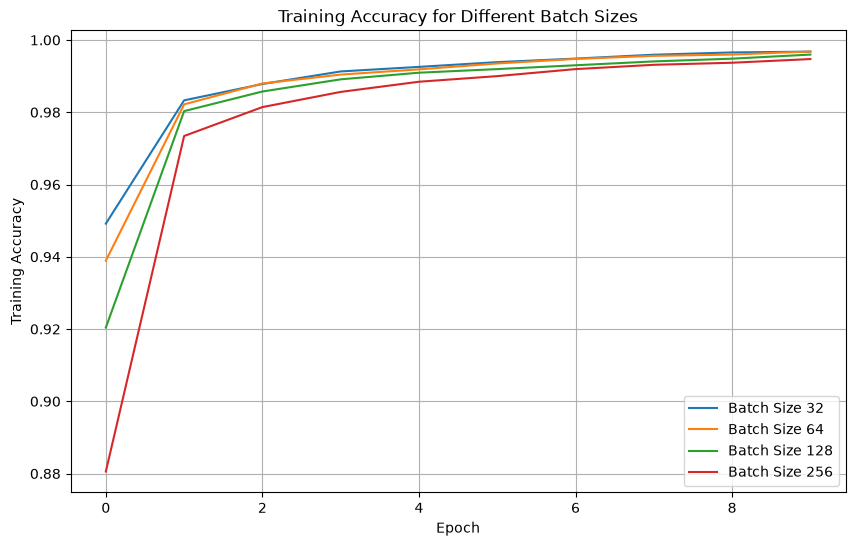

In [160]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_bs_32.history['accuracy'],
    label='Batch Size 32'
)

plt.plot(
    history_bs_64.history['accuracy'],
    label='Batch Size 64'
)

plt.plot(
    history_bs_128.history['accuracy'],
    label='Batch Size 128'
)

plt.plot(
    history_bs_256.history['accuracy'],
    label='Batch Size 256'
)

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy for Different Batch Sizes")
plt.legend()
plt.grid(True)

plt.show()

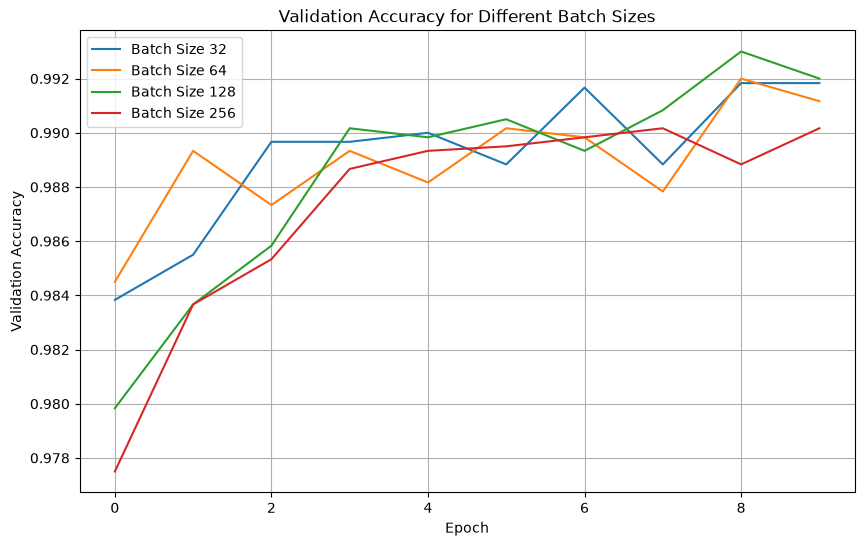

In [161]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_bs_32.history['val_accuracy'],
    label='Batch Size 32'
)

plt.plot(
    history_bs_64.history['val_accuracy'],
    label='Batch Size 64'
)

plt.plot(
    history_bs_128.history['val_accuracy'],
    label='Batch Size 128'
)

plt.plot(
    history_bs_256.history['val_accuracy'],
    label='Batch Size 256'
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy for Different Batch Sizes")
plt.legend()
plt.grid(True)

plt.show()

The best validation accuracy from your output was:

Batch 32: 99.18%
Batch 64: 99.20%
Batch 128: 99.30%
Batch 256: 98.83%

So Batch Size 128 is the best performer overall.


1. How does batch size affect training time?

Increasing the batch size generally reduces training time because fewer parameter-update steps are required per epoch.

In our experiment:

Batch 32 → 104.57 seconds
Batch 64 → 71.29 seconds
Batch 128 → 51.82 seconds
Batch 256 → 47.89 seconds

Therefore, the largest batch size of 256 trained fastest.

However, the reduction in training time does not necessarily mean better classification performance.

2. How does batch size affect convergence?

Batch size affects how frequently the model updates its weights.

Smaller batches provide more frequent weight updates and introduce more variation into the updates.
Larger batches provide smoother updates and require fewer updates per epoch.

In our experiment, Batch 32 required the longest training time, while larger batch sizes trained faster. However, Batch 128 achieved the highest validation accuracy, showing a good balance between stable and effective learning.

Batch 256 trained fastest but its validation accuracy was lower than Batch 128.

3. Which batch size gives the best validation accuracy?

Batch Size 128 gives the best validation accuracy.

The best validation accuracies were:

Batch Size	Best Validation Accuracy
32	99.18%
64	99.20%
128	99.30%
256	98.88%

Therefore, 128 provides the best validation performance in this experiment.

4. Is the largest batch size necessarily the best?

No, the largest batch size is not necessarily the best.

Although Batch Size 256 had the shortest training time (47.89 s), it achieved only 99.05% test accuracy and 98.88% best validation accuracy.

Batch Size 128 was slightly slower at 51.82 s, but achieved the highest test accuracy of 99.14% and the highest validation accuracy of 99.30%.

Therefore, the experiment shows that the largest batch size can improve computational efficiency, but a moderate batch size may provide better model performance. In this case, Batch Size 128 provides the best balance between training speed and classification accuracy.

# **H. Loss-function correctness experiment**

**Compare:**

**Experiment A**

Dense(10, activation='softmax')

loss = SparseCategoricalCrossentropy(from_logits=False)

**Experiment B**

Dense(10)

loss = SparseCategoricalCrossentropy(from_logits=True)

**Answer the following Questions**:

1. What is the difference between logits and probabilities?
2. Which combinations of output layer and loss function are mathematically consistent?
3. Compare accuracy and loss for both correct implementations.

In [162]:
model_loss_A = models.Sequential([
    layers.Conv2D(
        32, (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),

    layers.Dense(10, activation='softmax')
])

In [163]:
model_loss_A.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=False
    ),
    metrics=['accuracy']
)

In [164]:
start_time_loss_A = time.time()

history_loss_A = model_loss_A.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

training_time_loss_A = time.time() - start_time_loss_A

print("Experiment A Training Time:",
      training_time_loss_A, "seconds")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9411 - loss: 0.1957 - val_accuracy: 0.9813 - val_loss: 0.0601
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9821 - loss: 0.0575 - val_accuracy: 0.9805 - val_loss: 0.0693
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9871 - loss: 0.0409 - val_accuracy: 0.9862 - val_loss: 0.0497
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9895 - loss: 0.0324 - val_accuracy: 0.9880 - val_loss: 0.0453
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9920 - loss: 0.0249 - val_accuracy: 0.9883 - val_loss: 0.0484
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9936 - loss: 0.0201 - val_accuracy: 0.9903 - val_loss: 0.0422
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9945 - loss: 0.0170 - val_accuracy: 0.9898 - val_loss: 0.0407
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9952 - loss: 0.0140 - val_accuracy

In [165]:
test_loss_A_correct, test_accuracy_A_correct = model_loss_A.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("Experiment A Test Loss:",
      test_loss_A_correct)

print("Experiment A Test Accuracy:",
      test_accuracy_A_correct)

313/313 - 1s - 3ms/step - accuracy: 0.9894 - loss: 0.0384
Experiment A Test Loss: 0.03838202357292175
Experiment A Test Accuracy: 0.9894000291824341


In [166]:
model_loss_B = models.Sequential([
    layers.Conv2D(
        32, (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),

    layers.Dense(10)
])

In [167]:
layers.Dense(10)

<Dense name=dense_50, built=False>

In [168]:
model_loss_B.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    ),
    metrics=['accuracy']
)

In [169]:
start_time_loss_B = time.time()

history_loss_B = model_loss_B.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

training_time_loss_B = time.time() - start_time_loss_B

print("Experiment B Training Time:",
      training_time_loss_B, "seconds")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9412 - loss: 0.1954 - val_accuracy: 0.9852 - val_loss: 0.0532
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9835 - loss: 0.0539 - val_accuracy: 0.9905 - val_loss: 0.0411
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9880 - loss: 0.0382 - val_accuracy: 0.9883 - val_loss: 0.0378
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9911 - loss: 0.0286 - val_accuracy: 0.9888 - val_loss: 0.0432
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9924 - loss: 0.0235 - val_accuracy: 0.9888 - val_loss: 0.0348
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9936 - loss: 0.0194 - val_accuracy: 0.9907 - val_loss: 0.0343
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9945 - loss: 0.0165 - val_accuracy: 0.9887 - val_loss: 0.0370
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9954 - loss: 0.0136 - val_accuracy: 0

In [170]:
test_loss_B_correct, test_accuracy_B_correct = model_loss_B.evaluate(
    x_test_cnn,
    y_test,
    verbose=2
)

print("Experiment B Test Loss:",
      test_loss_B_correct)

print("Experiment B Test Accuracy:",
      test_accuracy_B_correct)

313/313 - 1s - 3ms/step - accuracy: 0.9882 - loss: 0.0437
Experiment B Test Loss: 0.043683890253305435
Experiment B Test Accuracy: 0.9882000088691711


In [171]:
print("========== LOSS FUNCTION COMPARISON ==========")

print("\nExperiment A")
print("Softmax + from_logits=False")
print("Parameters   :", model_loss_A.count_params())
print("Test Loss    :", test_loss_A_correct)
print("Test Accuracy:", test_accuracy_A_correct)
print("Training Time:", training_time_loss_A, "seconds")

print("\nExperiment B")
print("Logits + from_logits=True")
print("Parameters   :", model_loss_B.count_params())
print("Test Loss    :", test_loss_B_correct)
print("Test Accuracy:", test_accuracy_B_correct)
print("Training Time:", training_time_loss_B, "seconds")

========== LOSS FUNCTION COMPARISON ==========

Experiment A
Softmax + from_logits=False
Parameters   : 93322
Test Loss    : 0.03838202357292175
Test Accuracy: 0.9894000291824341
Training Time: 82.66170859336853 seconds

Experiment B
Logits + from_logits=True
Parameters   : 93322
Test Loss    : 0.043683890253305435
Test Accuracy: 0.9882000088691711
Training Time: 81.18265676498413 seconds


In [172]:
print("=" * 75)
print("LOSS FUNCTION CONVERGENCE ANALYSIS")
print("=" * 75)

loss_histories = {
    "Experiment A - Softmax": history_loss_A.history,
    "Experiment B - Logits": history_loss_B.history
}

for name, history in loss_histories.items():

    train_acc = history['accuracy']
    val_acc = history['val_accuracy']
    train_loss = history['loss']
    val_loss = history['val_loss']

    best_val_acc = max(val_acc)
    best_val_epoch = val_acc.index(best_val_acc) + 1

    min_val_loss = min(val_loss)
    min_val_loss_epoch = val_loss.index(min_val_loss) + 1

    print(f"\n{name}")
    print("-" * 55)

    print(f"Best Validation Accuracy : {best_val_acc:.6f}")
    print(f"Best Validation Epoch    : {best_val_epoch}")
    print(f"Minimum Validation Loss  : {min_val_loss:.6f}")
    print(f"Minimum Loss Epoch       : {min_val_loss_epoch}")

    print(f"Final Training Accuracy  : {train_acc[-1]:.6f}")
    print(f"Final Validation Accuracy: {val_acc[-1]:.6f}")
    print(f"Final Training Loss      : {train_loss[-1]:.6f}")
    print(f"Final Validation Loss    : {val_loss[-1]:.6f}")

print("\n" + "=" * 75)
print("EPOCH-WISE VALIDATION ACCURACY")
print("=" * 75)

print(
    f"{'Epoch':<8}"
    f"{'Softmax':<18}"
    f"{'Logits':<18}"
)

for i in range(10):
    print(
        f"{i+1:<8}"
        f"{history_loss_A.history['val_accuracy'][i]:<18.6f}"
        f"{history_loss_B.history['val_accuracy'][i]:<18.6f}"
    )

print("\n" + "=" * 75)
print("EPOCH-WISE VALIDATION LOSS")
print("=" * 75)

print(
    f"{'Epoch':<8}"
    f"{'Softmax':<18}"
    f"{'Logits':<18}"
)

for i in range(10):
    print(
        f"{i+1:<8}"
        f"{history_loss_A.history['val_loss'][i]:<18.6f}"
        f"{history_loss_B.history['val_loss'][i]:<18.6f}"
    )

LOSS FUNCTION CONVERGENCE ANALYSIS

Experiment A - Softmax
-------------------------------------------------------
Best Validation Accuracy : 0.992333
Best Validation Epoch    : 8
Minimum Validation Loss  : 0.038059
Minimum Loss Epoch       : 10
Final Training Accuracy  : 0.996611
Final Validation Accuracy: 0.991667
Final Training Loss      : 0.010006
Final Validation Loss    : 0.038059

Experiment B - Logits
-------------------------------------------------------
Best Validation Accuracy : 0.991500
Best Validation Epoch    : 8
Minimum Validation Loss  : 0.034299
Minimum Loss Epoch       : 6
Final Training Accuracy  : 0.996833
Final Validation Accuracy: 0.990167
Final Training Loss      : 0.009467
Final Validation Loss    : 0.042014

EPOCH-WISE VALIDATION ACCURACY
Epoch   Softmax           Logits            
1       0.981333          0.985167          
2       0.980500          0.990500          
3       0.986167          0.988333          
4       0.988000          0.988833          


1. What is the difference between logits and probabilities?

Logits are the raw numerical outputs produced by the final neural network layer before applying the Softmax function. They are not restricted to the range 0–1 and do not directly represent probabilities.

Probabilities are obtained by applying the Softmax function to the logits. They are values between 0 and 1, and the probabilities for all 10 classes sum to 1.

Therefore:

Logits → Softmax → Probabilities

In Experiment A, the model directly produces probabilities using Softmax. In Experiment B, the model produces raw logits and the loss function internally handles the required conversion.

2. Which combinations of output layer and loss function are mathematically consistent?

The following combinations are mathematically consistent:

Output Layer	Loss Function
Dense(10, activation='softmax')	SparseCategoricalCrossentropy(from_logits=False)
Dense(10)	SparseCategoricalCrossentropy(from_logits=True)

Thus, Experiment A and Experiment B are both correct implementations.

An incorrect combination would be using a Softmax output together with from_logits=True, because the output is already converted into probabilities and is no longer raw logits.

3. Compare accuracy and loss for both correct implementations.

Both correct implementations achieved very similar MNIST classification performance.

Experiment A: Test accuracy = 98.94%, test loss = 0.0384
Experiment B: Test accuracy = 98.82%, test loss = 0.0437

Experiment A performed slightly better in this particular run, with approximately 0.12 percentage points higher test accuracy and a lower test loss.

The validation results were also very close:

Experiment A best validation accuracy: 99.23%
Experiment B best validation accuracy: 99.15%

Therefore, the experiment shows that both mathematically correct combinations can achieve high classification accuracy. The small difference in accuracy is due to the particular training run rather than a fundamental correctness difference between the two approaches.